<a href="https://colab.research.google.com/github/SahilKumar777/ML-AI-Projects/blob/main/DecisionTrees/Activity_Recoginition_Pipelined_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Project Title**: **Activity Classification of Healthy Older People**
---
### ---> **Sahil Kumar 777**

Sequential motion data from 14 healthy older people aged 66 to 86 years old using a batteryless, wearable sensor on top of their clothing for the recognition of activities in clinical environments

* Objective :- Predict Activity of older people using classification methods
* Algo Used :- Decision Tree, Random forest, XGBoost

## Data Loading and Preprocessing


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### Datset Loading

#### Downloading

In [2]:
from pathlib import Path

if Path("data/raw").exists()==False :
  !mkdir data/
  !mkdir data/raw
  !mkdir data/processed

In [3]:
# Data downloading from the URL
!wget "https://github.com/SahilKumar777/ML-AI-Projects/raw/refs/heads/main/DecisionTrees/DatasetActivity.zip" -O data/raw/dataset.zip

--2025-03-21 06:38:07--  https://github.com/SahilKumar777/ML-AI-Projects/raw/refs/heads/main/DecisionTrees/DatasetActivity.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/SahilKumar777/ML-AI-Projects/refs/heads/main/DecisionTrees/DatasetActivity.zip [following]
--2025-03-21 06:38:08--  https://raw.githubusercontent.com/SahilKumar777/ML-AI-Projects/refs/heads/main/DecisionTrees/DatasetActivity.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 654610 (639K) [application/zip]
Saving to: ‘data/raw/dataset.zip’

data/raw/dataset.zi 100%[===================>] 639.27K  --.-KB/s    in 0.06s   

20

In [4]:
!unzip data/raw/dataset.zip -d data/raw/ -x S1_Dataset S2_Dataset

Archive:  data/raw/dataset.zip
  inflating: data/raw/S2_Dataset/d2p01F  
  inflating: data/raw/S2_Dataset/d2p02F  
  inflating: data/raw/S2_Dataset/d2p03F  
  inflating: data/raw/S2_Dataset/d2p04F  
  inflating: data/raw/S2_Dataset/d2p05F  
  inflating: data/raw/S2_Dataset/d2p06F  
  inflating: data/raw/S2_Dataset/d2p07F  
  inflating: data/raw/S2_Dataset/d2p08F  
  inflating: data/raw/S2_Dataset/d2p09F  
  inflating: data/raw/S2_Dataset/d2p10F  
  inflating: data/raw/S2_Dataset/d2p11F  
  inflating: data/raw/S2_Dataset/d2p12F  
  inflating: data/raw/S2_Dataset/d2p13F  
  inflating: data/raw/S2_Dataset/d2p14F  
  inflating: data/raw/S2_Dataset/d2p15F  
  inflating: data/raw/S2_Dataset/d2p16F  
  inflating: data/raw/S2_Dataset/d2p17F  
  inflating: data/raw/S2_Dataset/d2p18M  
  inflating: data/raw/S2_Dataset/d2p19M  
  inflating: data/raw/S2_Dataset/d2p20M  
  inflating: data/raw/S2_Dataset/d2p21M  
  inflating: data/raw/S2_Dataset/d2p22M  
  inflating: data/raw/S2_Dataset/d2p23F  
  i

In [5]:
!sudo apt install tree -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 29 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (91.3 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package tree.
(Reading database ... 126209 files and directories currently instal

In [6]:
!tree data

data
├── processed
└── raw
    ├── dataset.zip
    ├── S1_Dataset
    │   ├── d1p01M
    │   ├── d1p02M
    │   ├── d1p03M
    │   ├── d1p04M
    │   ├── d1p05M
    │   ├── d1p06M
    │   ├── d1p07M
    │   ├── d1p08F
    │   ├── d1p09F
    │   ├── d1p10F
    │   ├── d1p11F
    │   ├── d1p12F
    │   ├── d1p13F
    │   ├── d1p14F
    │   ├── d1p15F
    │   ├── d1p16F
    │   ├── d1p17F
    │   ├── d1p18F
    │   ├── d1p19F
    │   ├── d1p20F
    │   ├── d1p21F
    │   ├── d1p22F
    │   ├── d1p23F
    │   ├── d1p24F
    │   ├── d1p25F
    │   ├── d1p26F
    │   ├── d1p27F
    │   ├── d1p28F
    │   ├── d1p29F
    │   ├── d1p30F
    │   ├── d1p31F
    │   ├── d1p32F
    │   ├── d1p33F
    │   ├── d1p34F
    │   ├── d1p35F
    │   ├── d1p36M
    │   ├── d1p37M
    │   ├── d1p38M
    │   ├── d1p39M
    │   ├── d1p40M
    │   ├── d1p41M
    │   ├── d1p42M
    │   ├── d1p43M
    │   ├── d1p44M
    │   ├── d1p45M
    │   ├── d1p46M
    │   ├── d1p47M
    │   ├── d1p48M
    │   ├── d1p49F
   

In [7]:
import os

data_dir = "data/raw/"
folders = ["S1_Dataset", "S2_Dataset"]

def load_data():
    all_data = []  # List to store DataFrames

    for folder in folders:
        folder_path = os.path.join(data_dir, folder)
        for file in os.listdir(folder_path):
            # Updated filter condition to include files that start with 'd' or end with '.txt' (excluding README.txt)
            if (file.lower().endswith(".txt") or file.lower().startswith("d")) and file.lower() != "readme.txt":
                file_path = os.path.join(folder_path, file)

                try:
                    df = pd.read_csv(file_path, header=None)
                    df["file"] = file  # Track source file
                    all_data.append(df)
                except Exception as e:
                    print(f"Error loading {file}: {e}")

    # Combine all data
    full_df = pd.concat(all_data, ignore_index=True)
    return full_df


#### Load Dataset

In [8]:
# Load dataset
df = load_data()

# Naming Dataset Columns
df.columns = ['Time', 'Frontal_Accel', 'Vertical_Accel', 'Lateral_Accel', 'Sensor_ID', 'RSSI', 'Phase', 'Frequency', 'Activity_Label', 'Filename']
print("\n Data Loaded Successfully!\n", df)
df1=df


 Data Loaded Successfully!
           Time  Frontal_Accel  Vertical_Accel  Lateral_Accel  Sensor_ID  RSSI  \
0        0.000        0.31893         0.99674       0.088944          4 -57.5   
1        0.025        0.31893         0.99674       0.088944          1 -56.5   
2        0.250        0.31893         0.99674       0.088944          4 -58.5   
3        0.500        0.31893         0.99674       0.088944          1 -57.0   
4        0.550        0.31893         0.99674       0.088944          1 -57.5   
...        ...            ...             ...            ...        ...   ...   
75123  908.250        0.91693         0.72114       0.123150          1 -57.5   
75124  910.000        0.77622         0.77856       0.054735          1 -58.0   
75125  911.000        0.77622         0.77856       0.054735          1 -58.0   
75126  912.000        0.77622         0.77856       0.054735          1 -59.5   
75127  918.250        0.34238         0.95081      -0.093505          1 -58.0   

### Dataset Information

In [9]:
# Get Size of dataset

print("Number Of Rows in Dataset = ",df.shape[0])
print("Number Of Features in Dataset = ",df.shape[1])

Number Of Rows in Dataset =  75128
Number Of Features in Dataset =  10


In [10]:
# Dataset Features info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75128 entries, 0 to 75127
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Time            75128 non-null  float64
 1   Frontal_Accel   75128 non-null  float64
 2   Vertical_Accel  75128 non-null  float64
 3   Lateral_Accel   75128 non-null  float64
 4   Sensor_ID       75128 non-null  int64  
 5   RSSI            75128 non-null  float64
 6   Phase           75128 non-null  float64
 7   Frequency       75128 non-null  float64
 8   Activity_Label  75128 non-null  int64  
 9   Filename        75128 non-null  object 
dtypes: float64(7), int64(2), object(1)
memory usage: 5.7+ MB


In [11]:
# Observe Top 20 Rows
df.head(20)

,Time,Frontal_Accel,Vertical_Accel,Lateral_Accel,Sensor_ID,RSSI,Phase,Frequency,Activity_Label,Filename
0,0.000,0.31893,0.99674,0.088944,4,-57.5,1.500200,924.75,1,d1p37M
1,0.025,0.31893,0.99674,0.088944,1,-56.5,5.154200,924.25,1,d1p37M
2,0.250,0.31893,0.99674,0.088944,4,-58.5,5.717100,924.25,1,d1p37M
3,0.500,0.31893,0.99674,0.088944,1,-57.0,5.591400,920.75,1,d1p37M
4,0.550,0.31893,0.99674,0.088944,1,-57.5,0.220890,923.25,1,d1p37M
5,0.750,0.31893,0.99674,0.088944,4,-57.0,4.824400,922.25,1,d1p37M
6,1.250,0.37756,0.91636,0.168760,1,-56.5,1.549300,921.75,1,d1p37M
7,1.500,0.37756,0.91636,0.168760,1,-59.0,4.416300,925.75,1,d1p37M
8,1.750,0.37756,0.91636,0.168760,1,-57.0,0.612060,922.75,1,d1p37M
9,2.250,0.37756,0.91636,0.168760,1,-58.0,5.086700,924.75,1,d1p37M


In [12]:
# Dataset Basic Statistics
df.describe()

,Time,Frontal_Accel,Vertical_Accel,Lateral_Accel,Sensor_ID,RSSI,Phase,Frequency,Activity_Label
count,75128.000000,75128.000000,75128.000000,75128.000000,75128.000000,75128.000000,75128.000000,75128.000000,75128.000000
mean,299.080416,0.714211,0.345199,-0.217477,2.409581,-58.277253,3.157279,922.670536,2.528378
std,257.503002,0.404585,0.419041,0.438219,1.102165,5.174083,2.182257,1.679093,0.864258
min,0.000000,-0.748080,-0.553490,-1.336400,1.000000,-72.000000,0.000000,920.250000,1.000000
25%,121.250000,0.342380,-0.002297,-0.184730,1.000000,-62.000000,1.032400,921.250000,2.000000
50%,250.715000,0.682420,0.215880,-0.070699,3.000000,-58.000000,2.767300,922.750000,3.000000
75%,402.500000,1.104500,0.858940,0.031928,3.000000,-56.000000,5.358575,924.250000,3.000000
max,1739.400000,1.503200,2.030200,1.217800,4.000000,-38.500000,6.281700,925.750000,4.000000


**Insights**

*   No missing data in any column
*   All columns have numerical data



**Feature Details**

1.  Time : Time in seconds of data recorded [0, 1739.4]
2.  Frontal_Accel : Acceleration reading in G in Frontal Axis
3.  Vertical_Accel : Acceleration reading in G in vertical Axis
4.  Lateral_Accel : Acceleration reading in G in perpendicular Axis
5.  Sensor ID : ID of antenna reading sensor
6.  RSSI : Received signal strength indicator
7.  Phase : Phase
8.  Frequency : Frequency
9.  Activity Label : Label of the activity performed

**Activity Class labels** assigned for every sensor observation are:
- Sitting on bed
- Sitting on chair
- Lying on bed
- Ambulating, where ambulating includes standing, walking around the room.



### Features Extraction (Creating new features)

In [13]:
# Last character of filename is gender
df['Gender'] = df.Filename.str[-1]
df.Gender.value_counts()

,count
Gender,
F,43828
M,31300


In [14]:
# Second character of filename is room number
df['Room'] = df.Filename.str[1].apply(int)
df.Room.value_counts()

,count
Room,
1,52482
2,22646


In [15]:
# The ending digits in the filename are person number or person ID
df['Person_ID'] = df.Filename.str[3:5].apply(int)

# Data count of every person
df.Person_ID.value_counts()

,count
Person_ID,
50,4638
53,4563
45,3339
2,3252
44,3139
51,3044
49,2876
47,2818
15,2665


In [16]:
# Data count of every file
df.Filename.value_counts()

df2=df

### Dataset Overview

In [17]:
# Plots Histogram and Boxplot of Given datafram and Column
def histBox_plot(df,col) :
  plt.figure(figsize=(12, 4))

  # Plot 1
  plt.subplot(2,1,1)
  plt.title('Distribution')
  sns.histplot(df[col], kde=True, bins=50)

  # Plot 2
  plt.subplot(2,1,2)
  plt.title('Boxplot')
  sns.boxplot(data=df, x=col)

  plt.tight_layout()
  plt.show()

In [18]:
# Plotting 2 features on x and y axis to get relationship between features
def plotColXY(df,colx,coly,mark='o', line='-') :
  plt.figure(figsize=(20, 5))
  plt.plot(df[colx], df[coly], marker=mark, linestyle=line)
  plt.title(colx +' vs ' + coly)
  plt.xlabel(colx)
  plt.ylabel(coly)
  plt.grid(True)
  plt.show()

In [19]:
# To get skewness and kurtosis of feature
from scipy.stats import skew, kurtosis

def skew_Kurtosis(df,col) :
  feature_skewness = skew(df[col])
  feature_kurtosis = kurtosis(df[col])
  print(f"Skewness: {feature_skewness},\nKurtosis: {feature_kurtosis}")

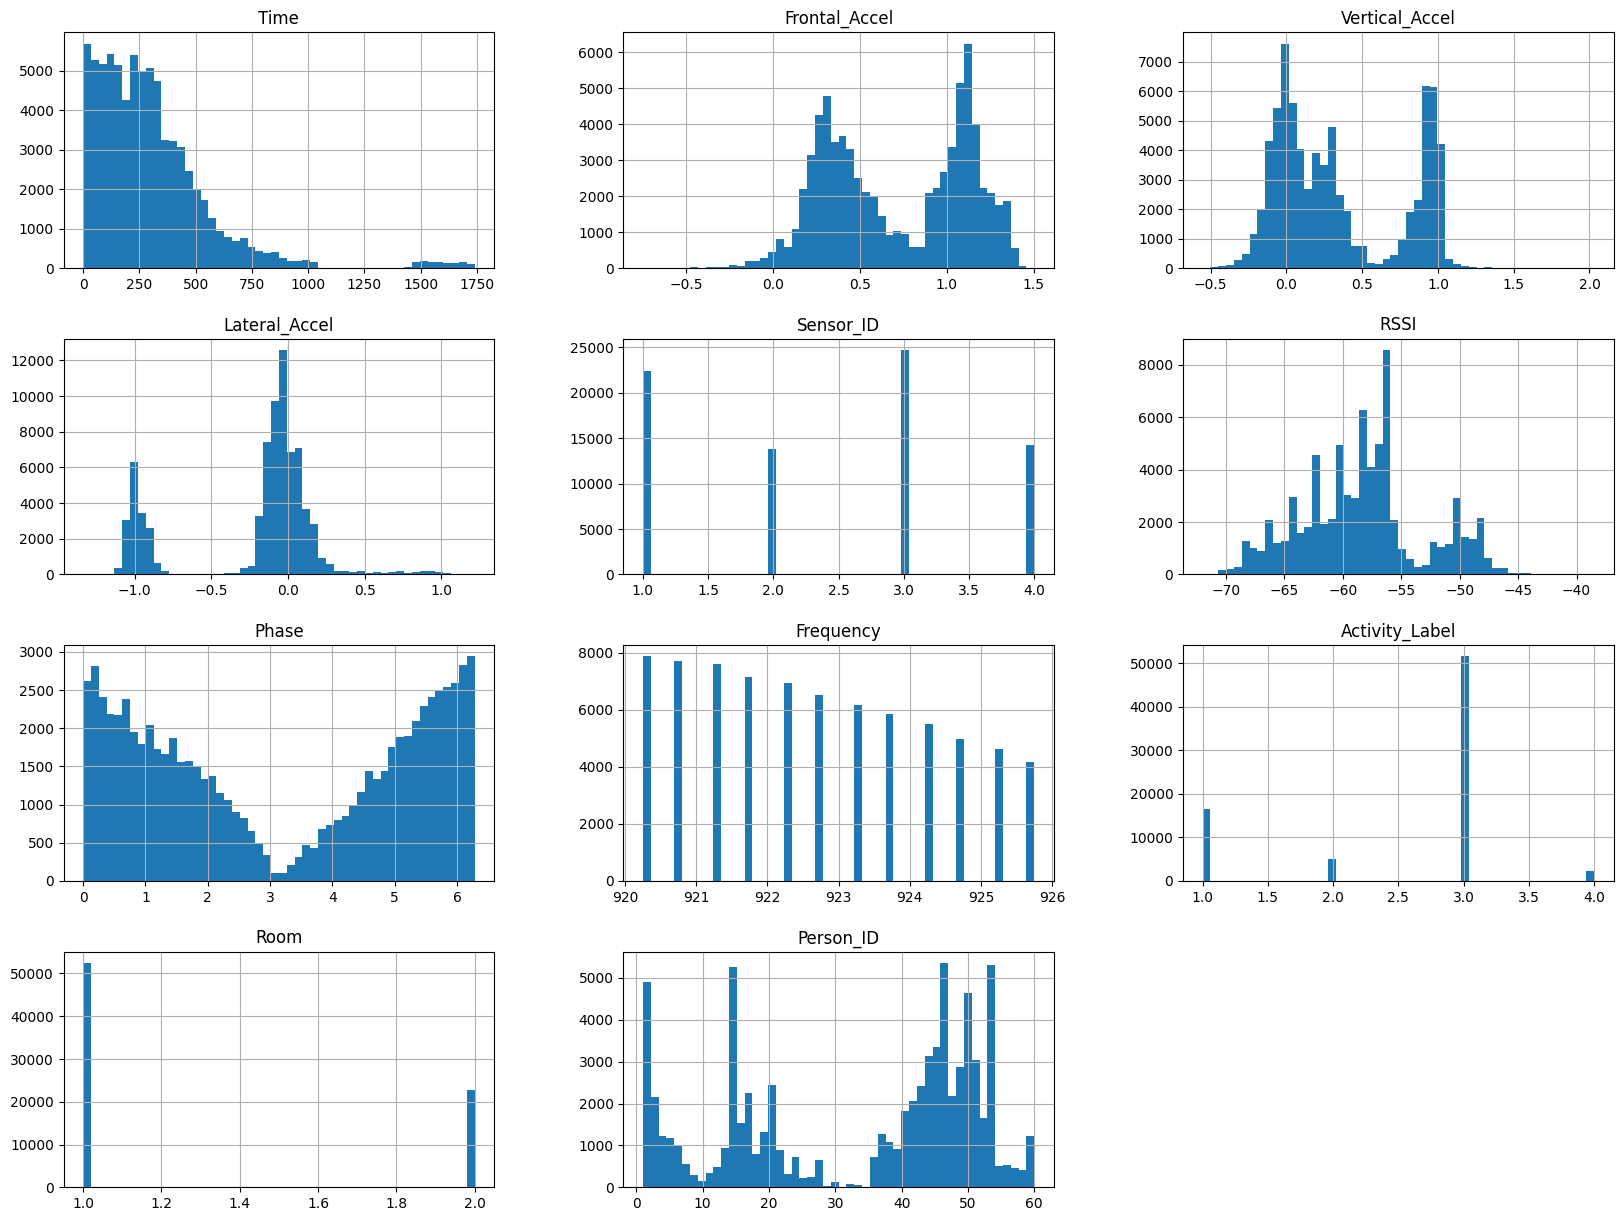

In [20]:
# Distribution of data
df.hist(figsize=(20,15),bins=50)
plt.show()

*   There is no data for Time in range around 1075 to 1425
*   Frontal_Accel, Vertical_Accel, Lateral_Accel and RSSI are Multimodal




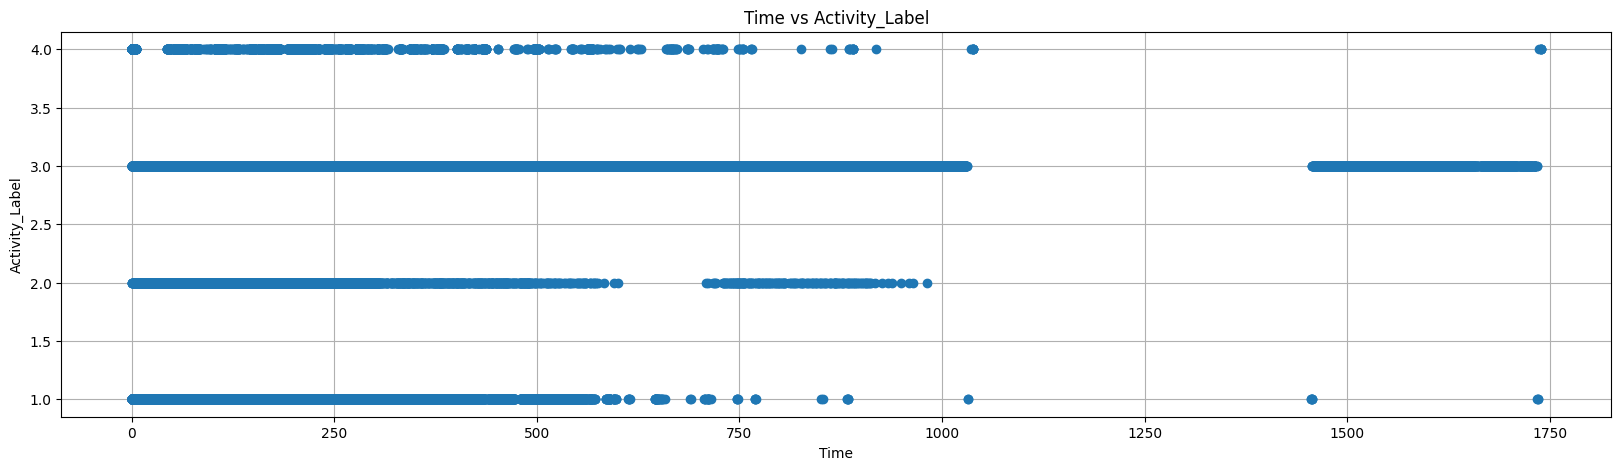

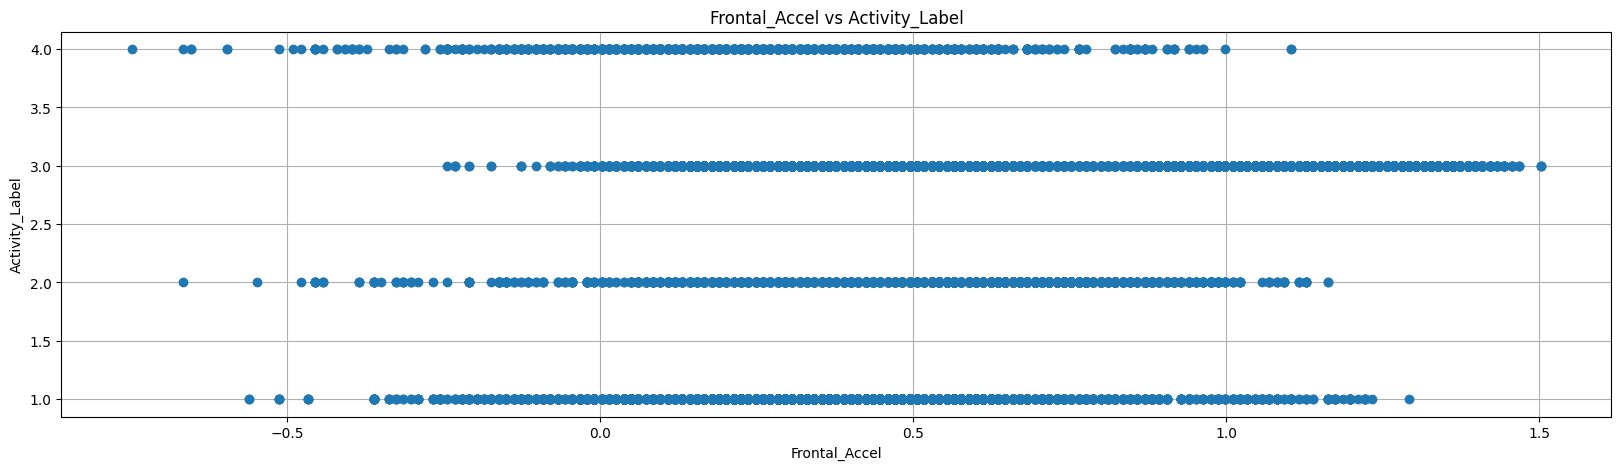

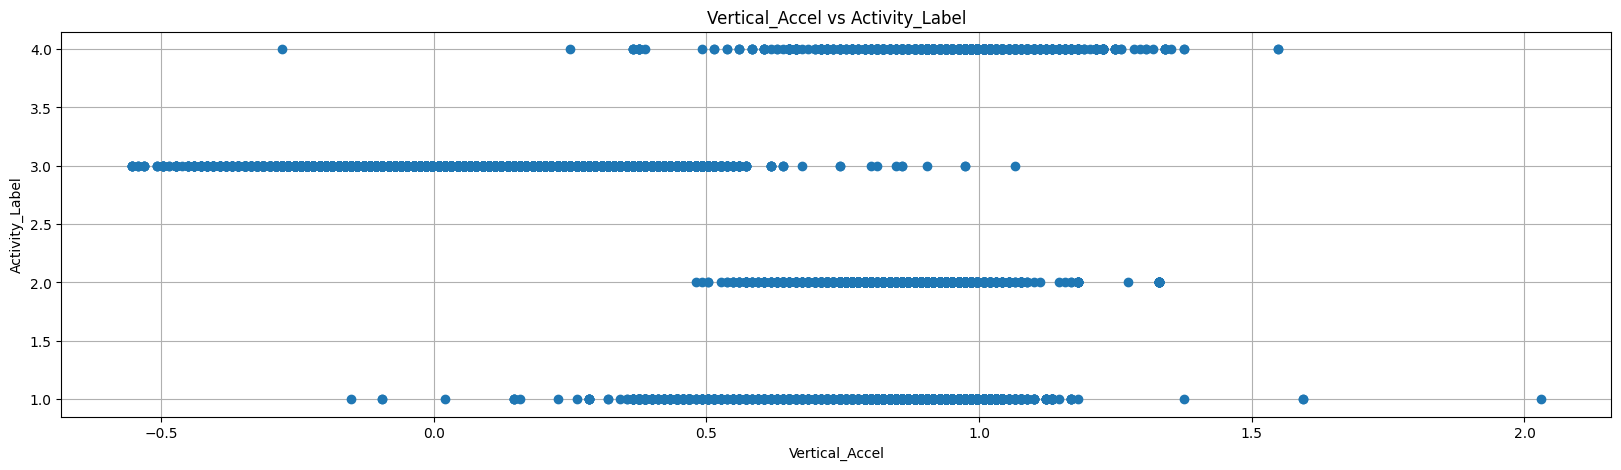

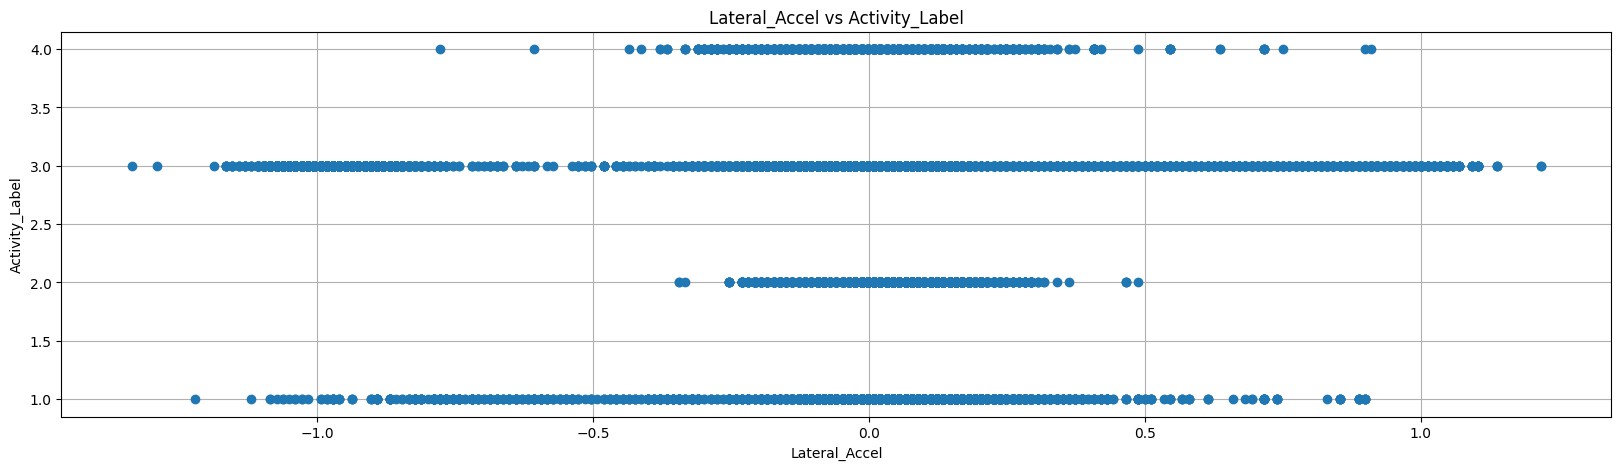

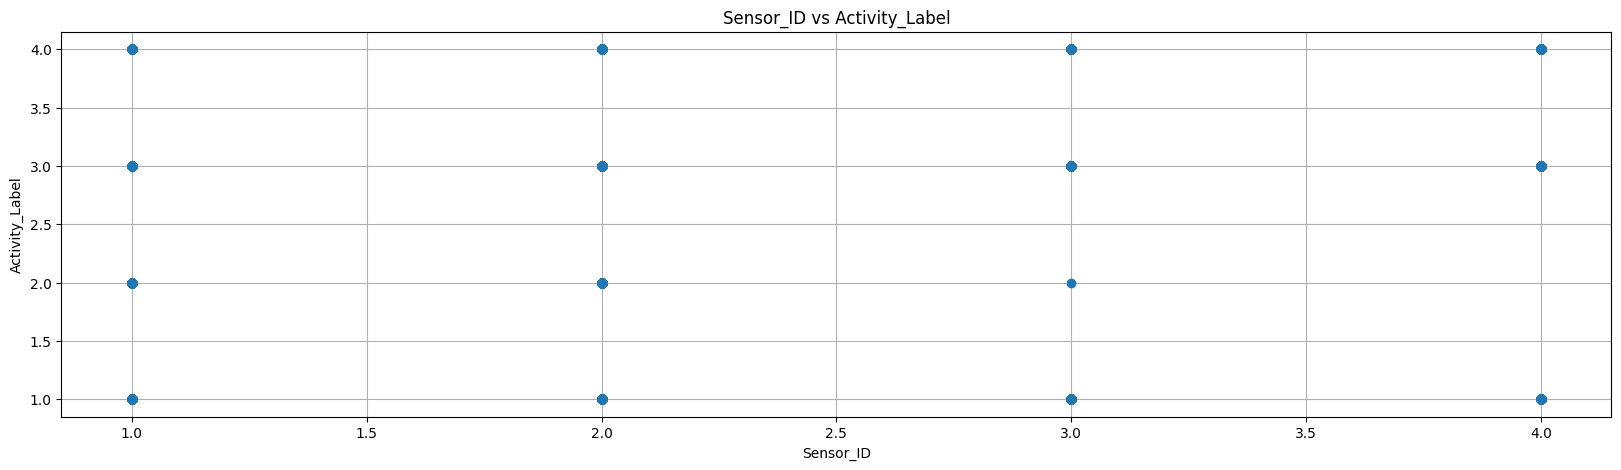

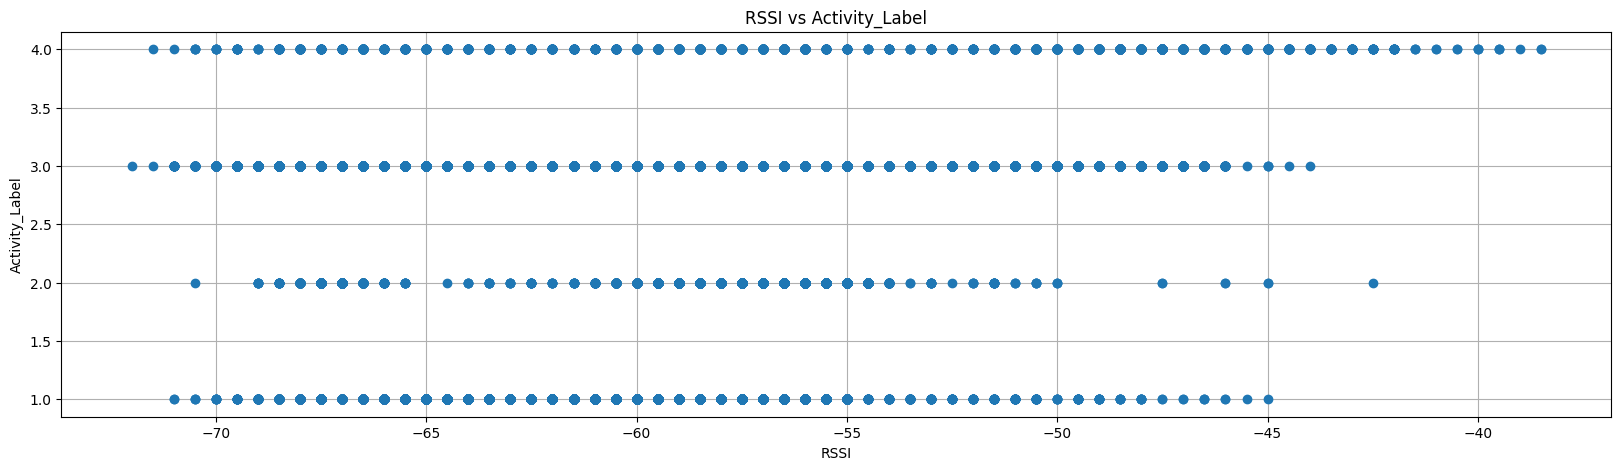

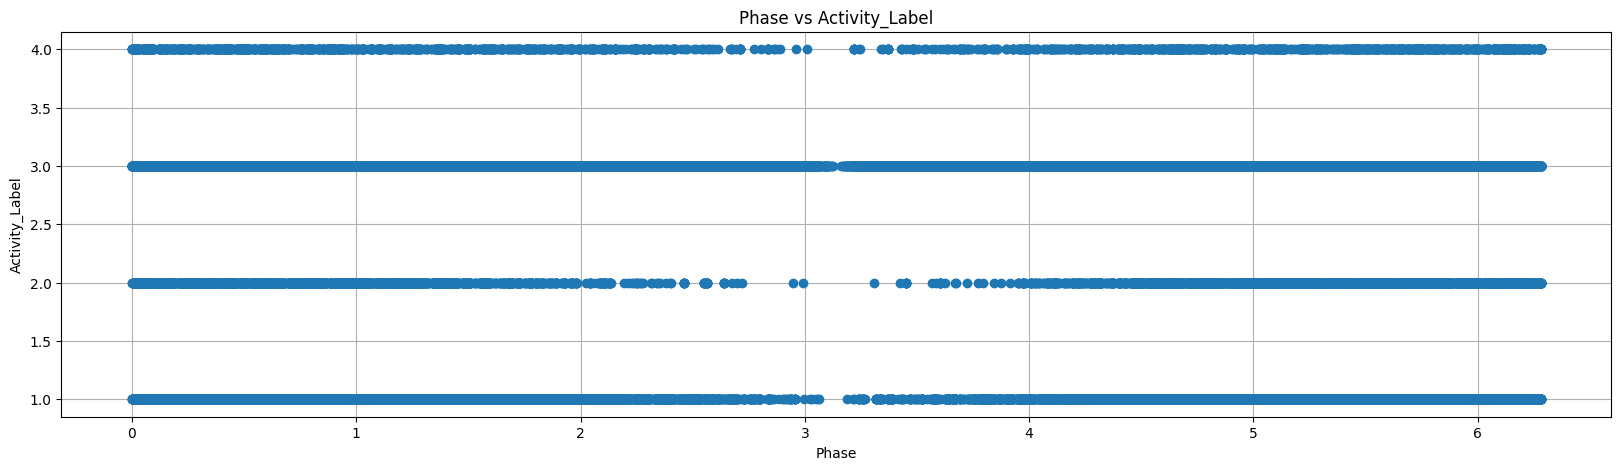

In [21]:
for col in ['Time', 'Frontal_Accel', 'Vertical_Accel', 'Lateral_Accel', 'Sensor_ID','RSSI', 'Phase'] :
  plotColXY(df,col,'Activity_Label',line='')

Individual File Data

In [22]:
# Finding Patterns in dataset
df_File1 = df[df.Filename=='d1p50F']

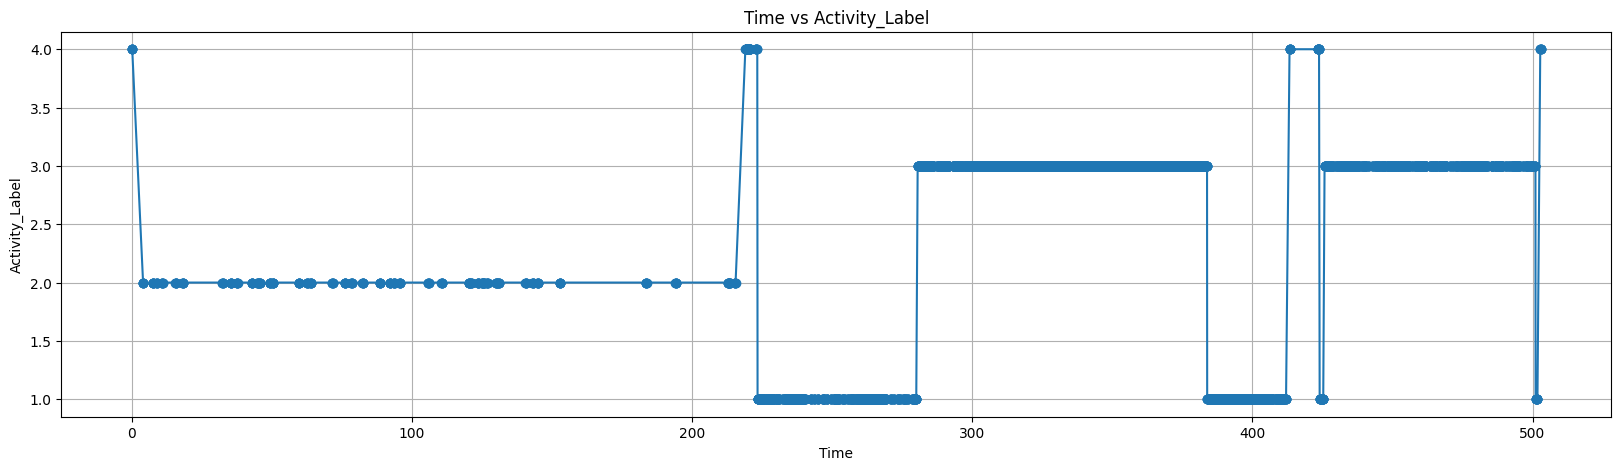

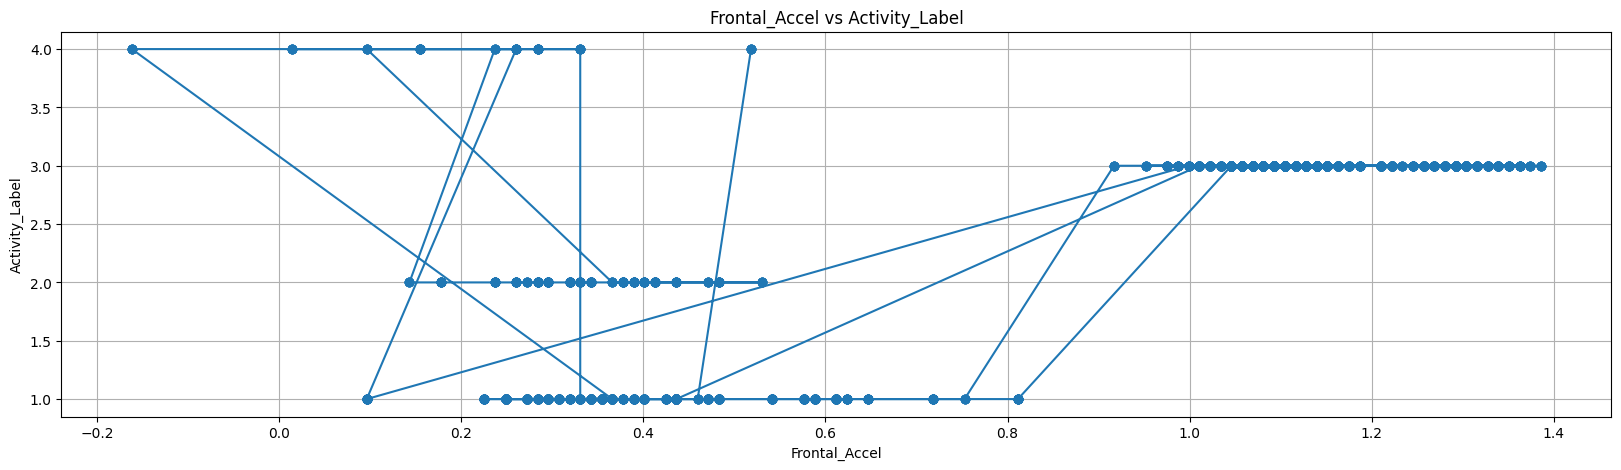

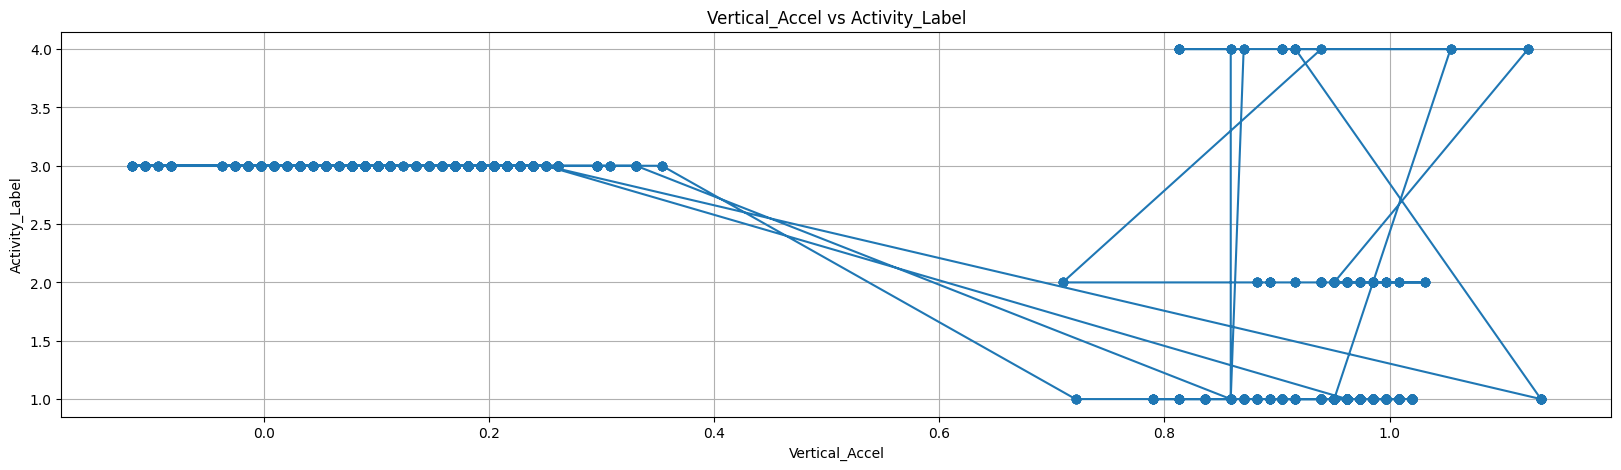

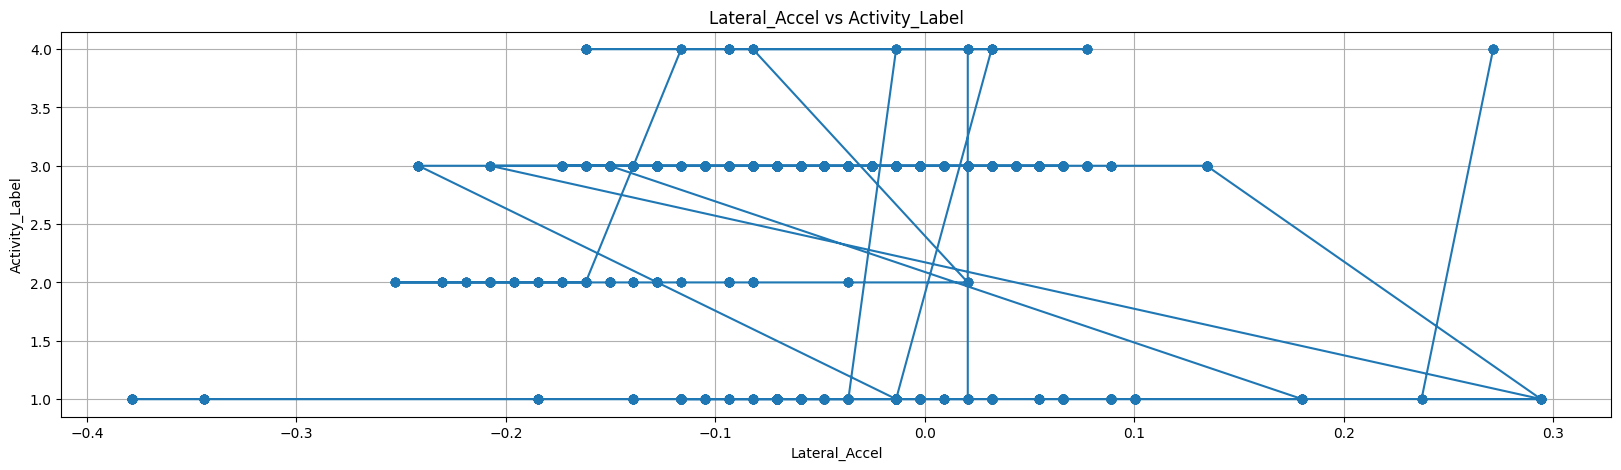

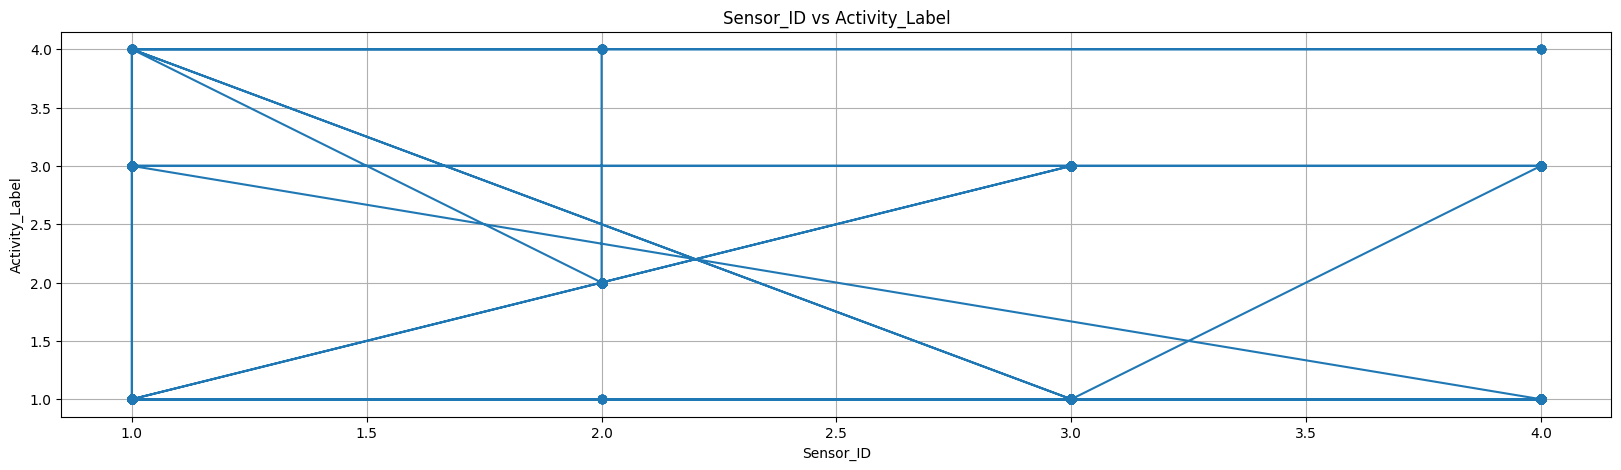

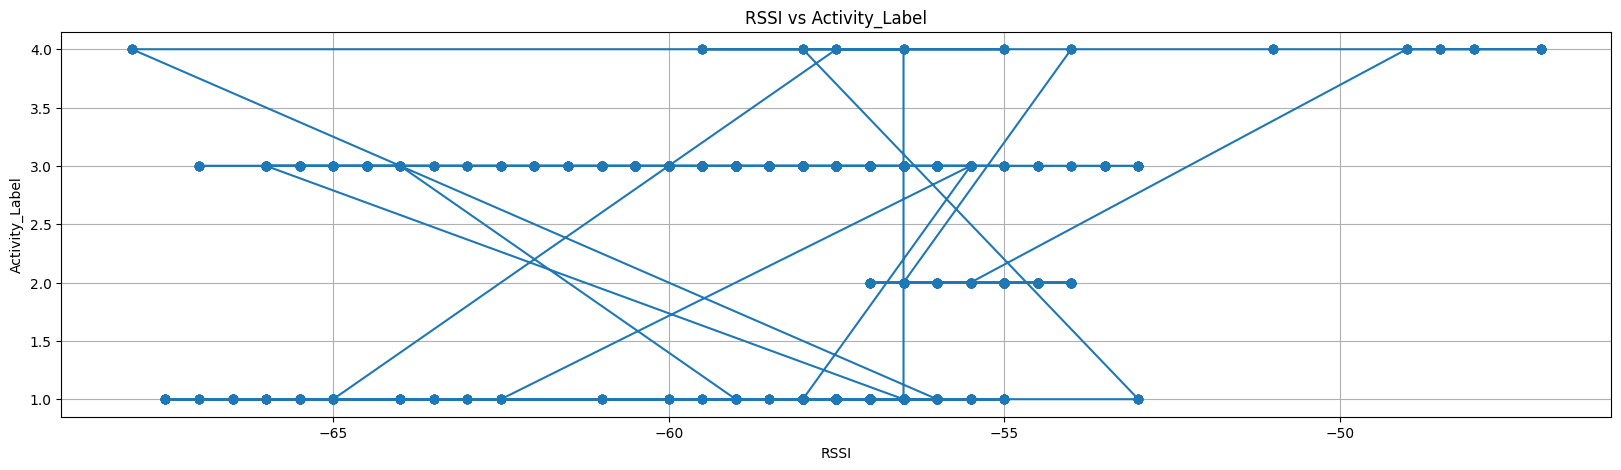

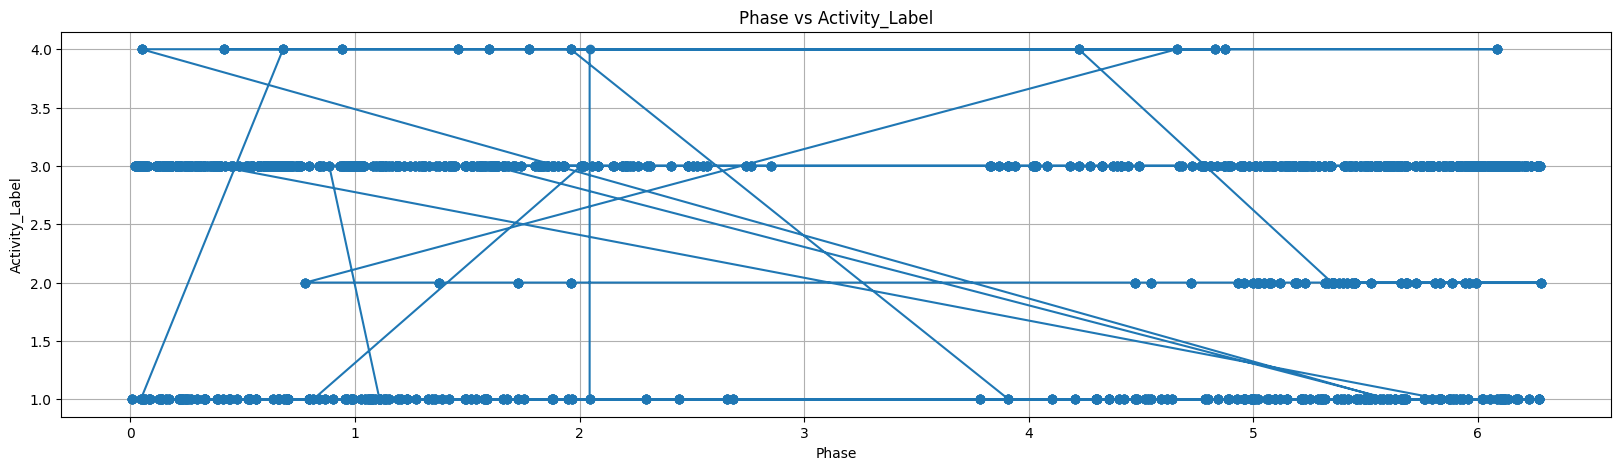

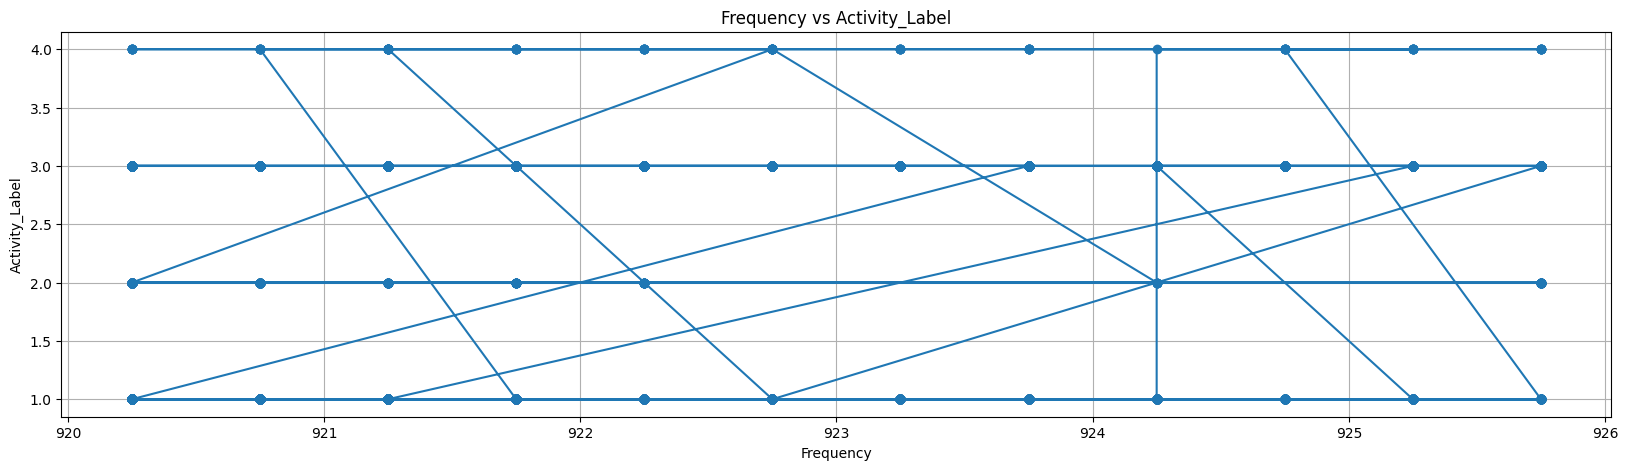

In [23]:
# Visualisations of columns data and relationships between columns
for col in ['Time', 'Frontal_Accel', 'Vertical_Accel', 'Lateral_Accel', 'Sensor_ID','RSSI', 'Phase', 'Frequency'] :
  plotColXY(df_File1,col,'Activity_Label')

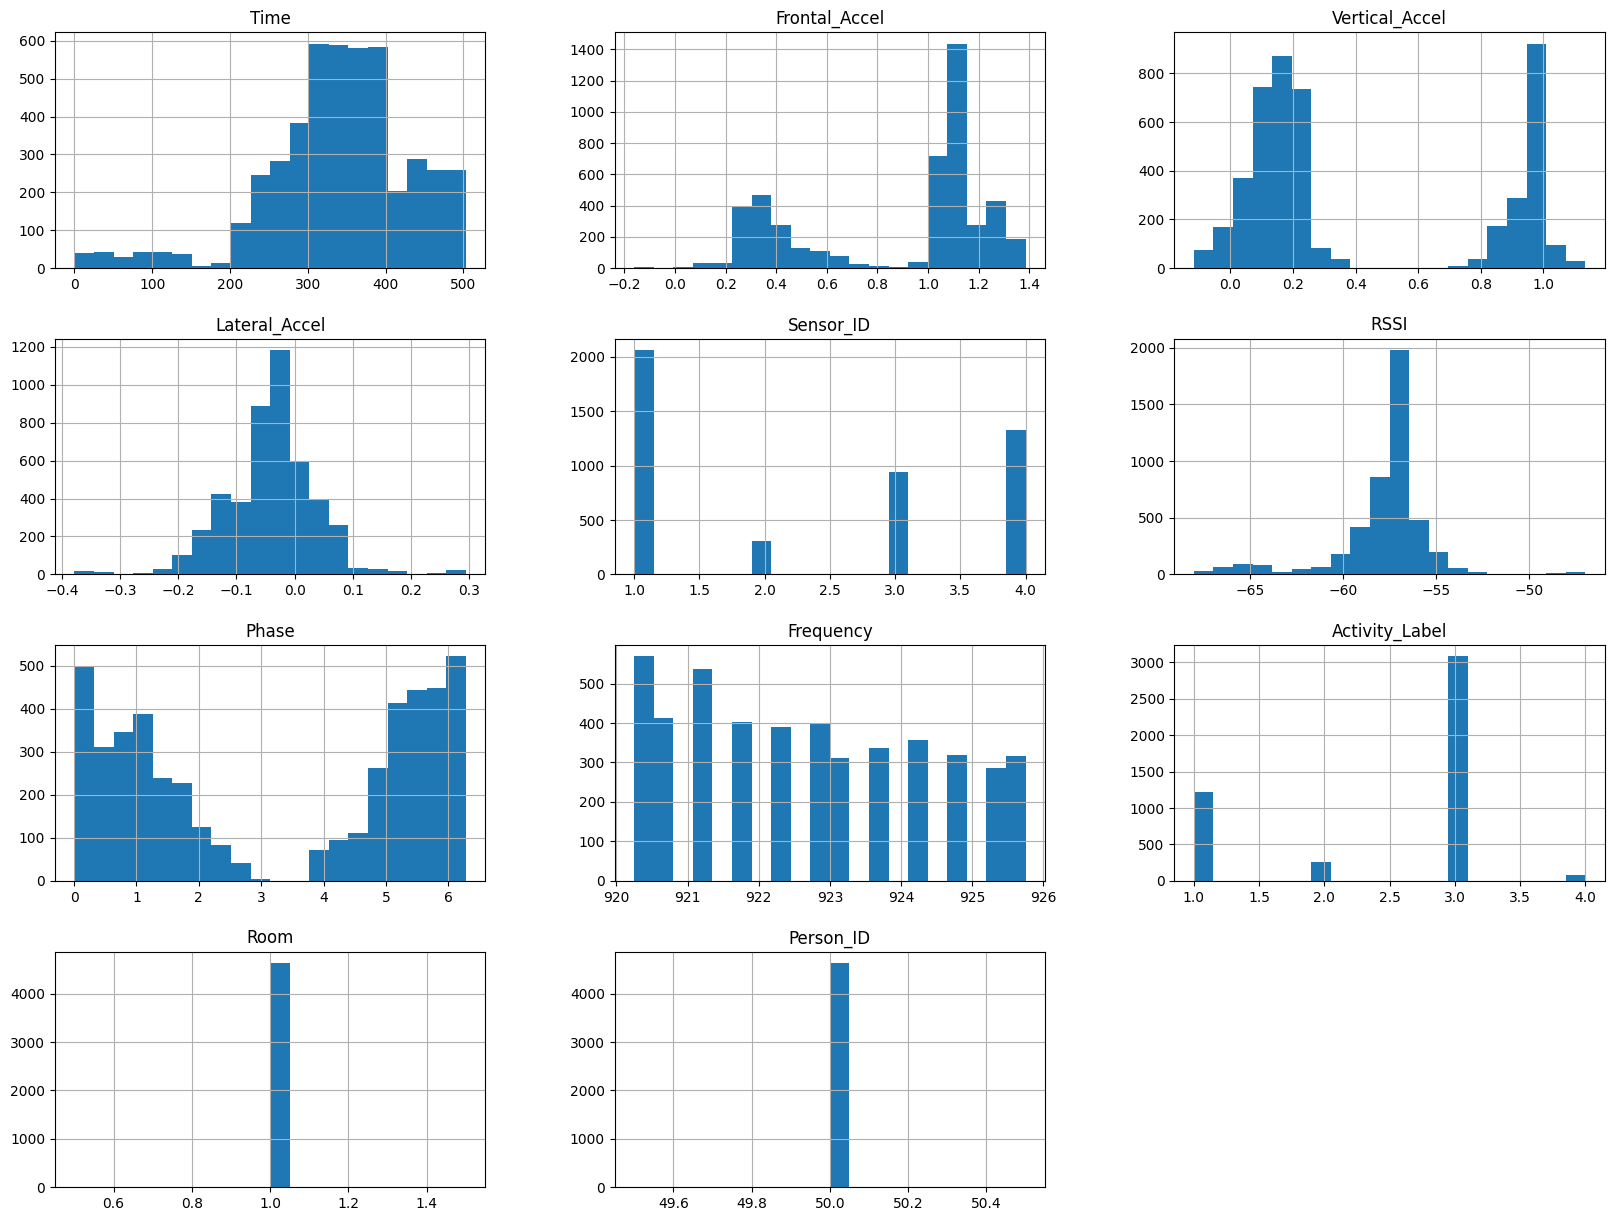

In [24]:
# Distribution of Column data
df_File1.hist(figsize=(20,15),bins=20)
plt.show()

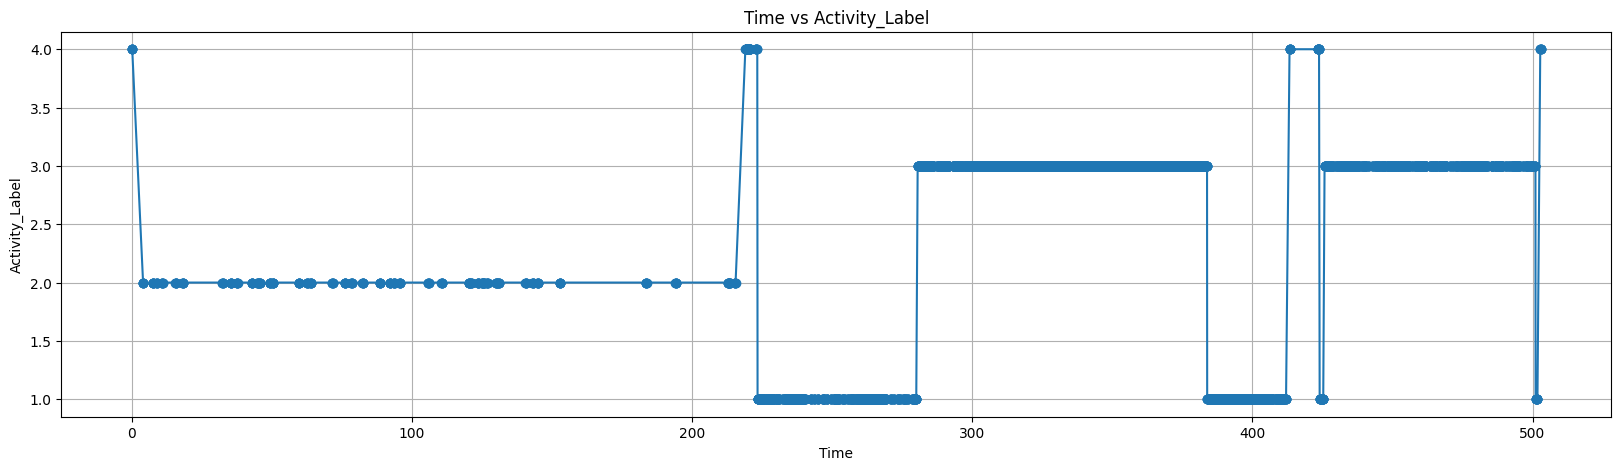

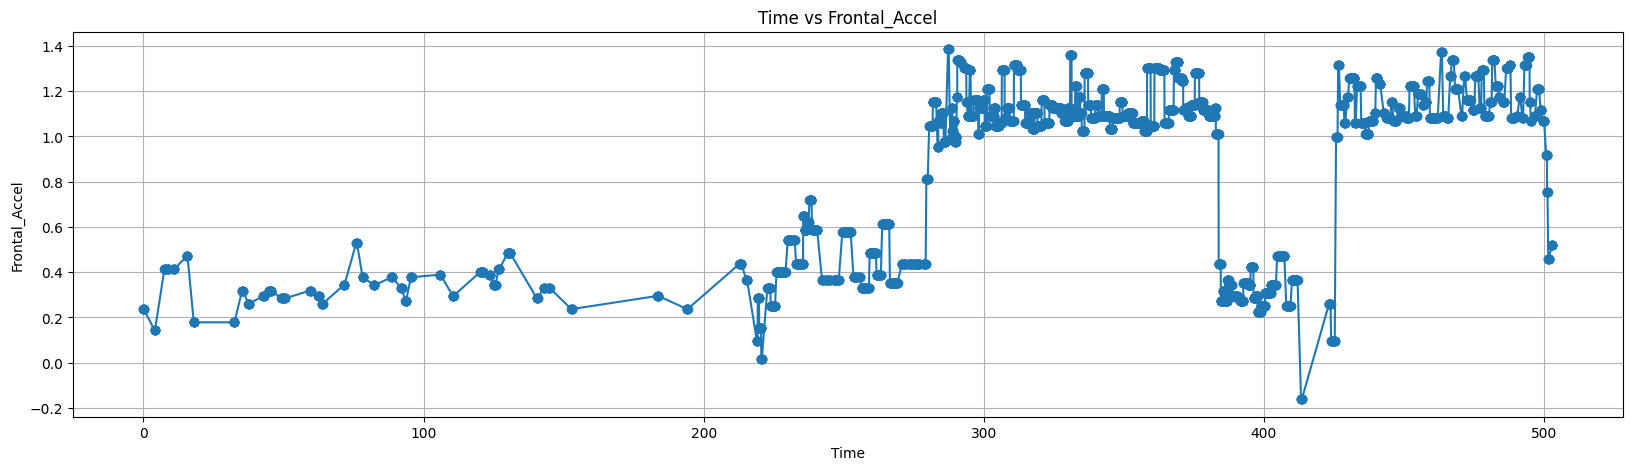

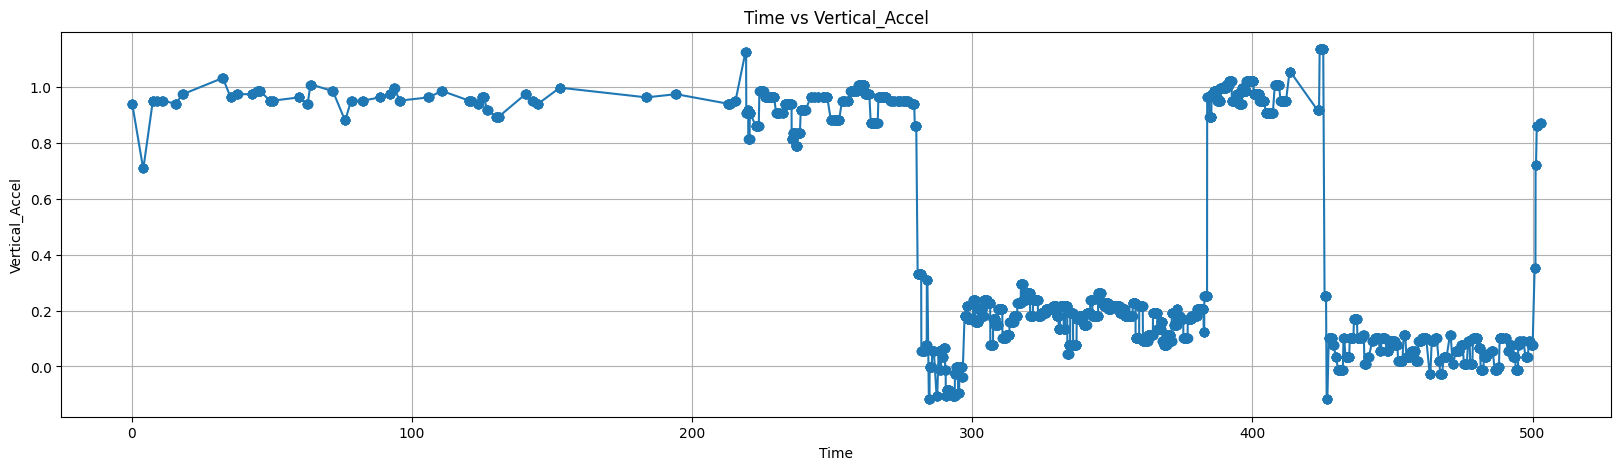

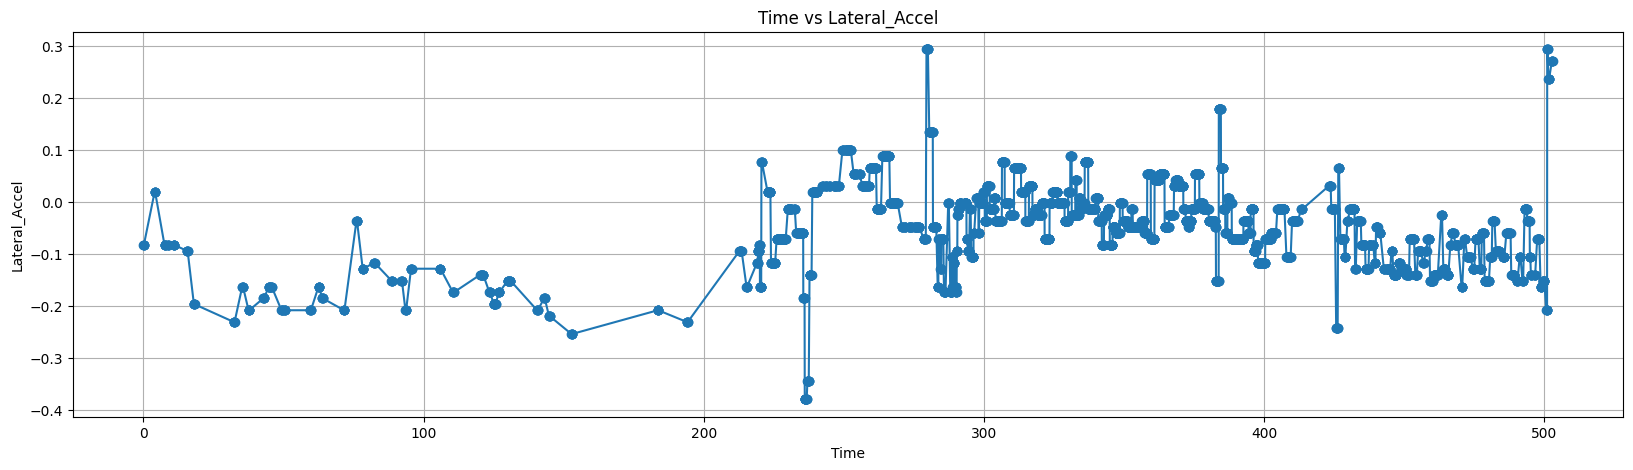

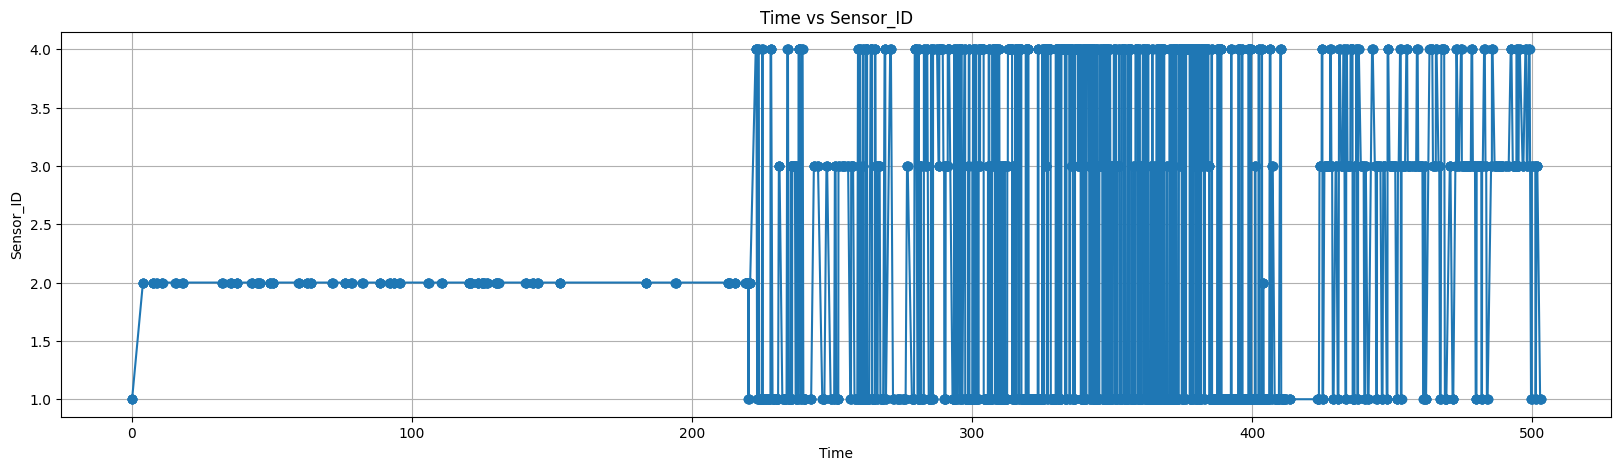

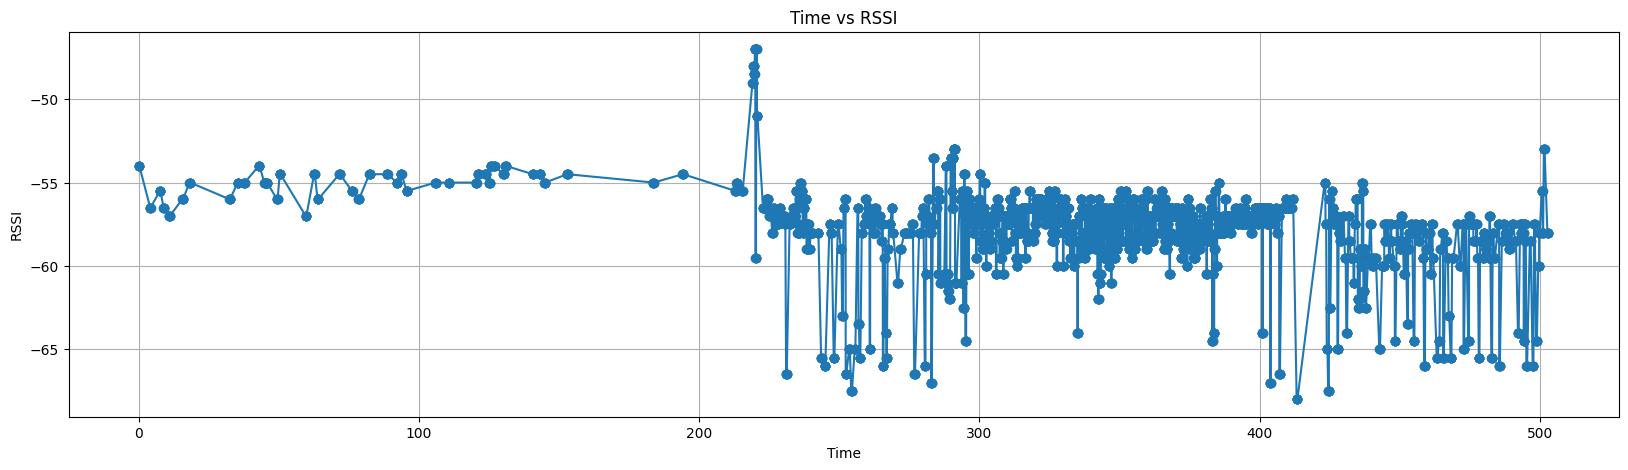

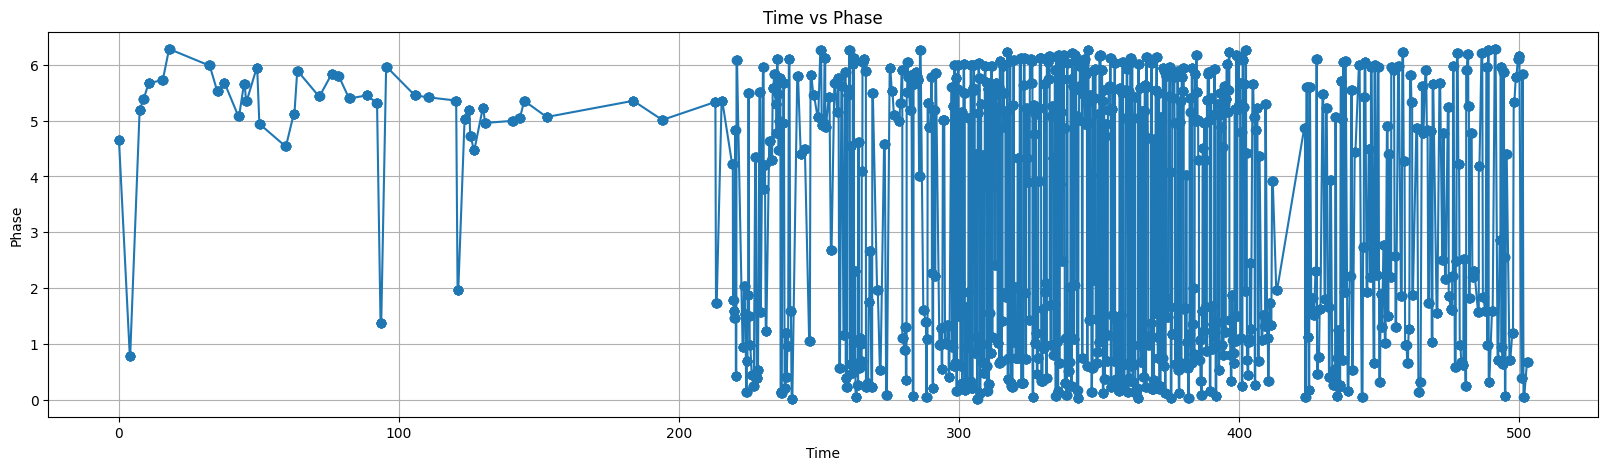

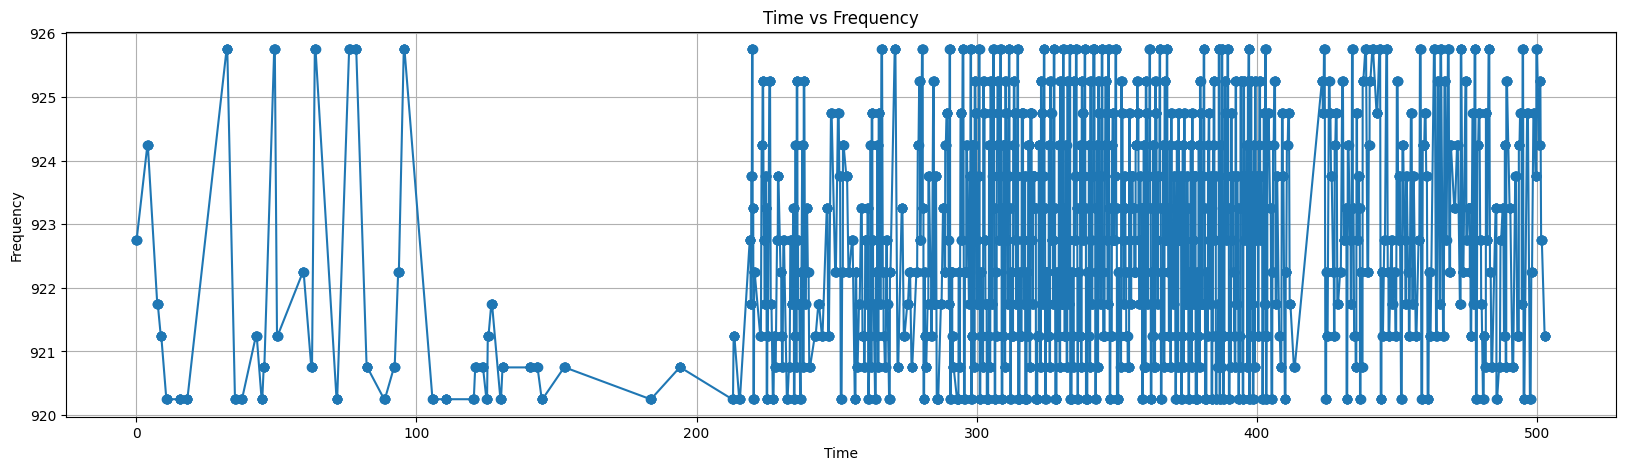

In [25]:
# Visualisations of columns data and relationships between columns
for col in ['Activity_Label', 'Frontal_Accel', 'Vertical_Accel', 'Lateral_Accel', 'Sensor_ID','RSSI', 'Phase', 'Frequency'] :
  plotColXY(df_File1,'Time',col)

## Data Preprocessing





### Data Cleaning

Missing Values

In [26]:
# Check Missing data percentage

total = df.isnull().sum().sort_values(ascending=False)
percent_1 = df.isnull().sum()/df.isnull().count()*100
percent_2 = (round(percent_1, 1)).sort_values(ascending=False)
missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
print("Total missing values : ",df.isnull().sum().sum())
missing_data

Total missing values :  0


,Total,%
Time,0,0.0
Frontal_Accel,0,0.0
Vertical_Accel,0,0.0
Lateral_Accel,0,0.0
Sensor_ID,0,0.0
RSSI,0,0.0
Phase,0,0.0
Frequency,0,0.0
Activity_Label,0,0.0
Filename,0,0.0


Duplicate Rows

In [27]:
# Check Duplicate rows
df.duplicated().sum()

np.int64(2)

In [28]:
df = df.drop_duplicates()

Anomalies Detection
*   Outliers using boxplots
*   Calculating Outliers
 * Z-Score (For Normally Distributed Data)
 * Inter Quartile Range (IQR) for skewed as well as Normally Distributed
*   Handling Outliers
 * Dropping Errorneous Outliers
 * Trimming and Capping Extreme Outliers
 * Winsorization (Capping data upto a percentile ex-[5%-90%])


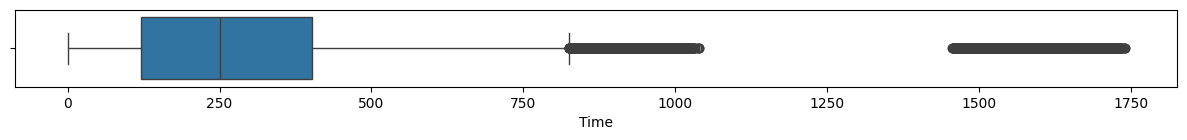

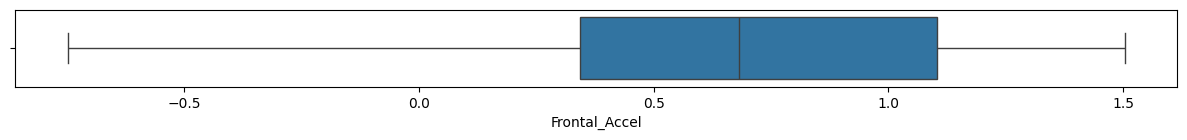

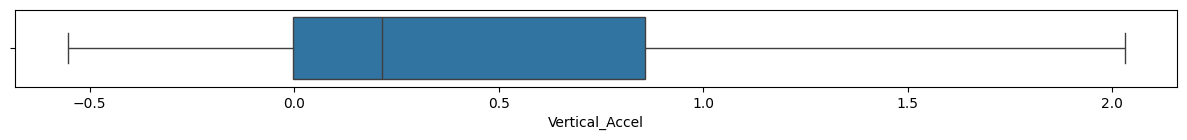

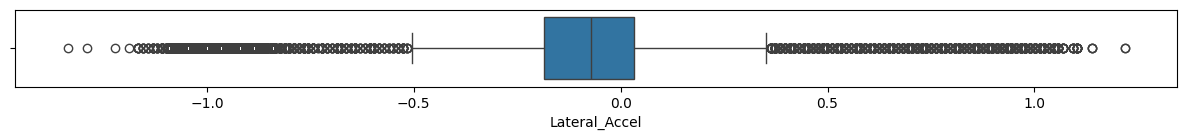

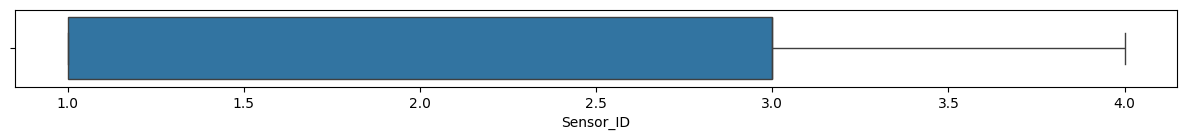

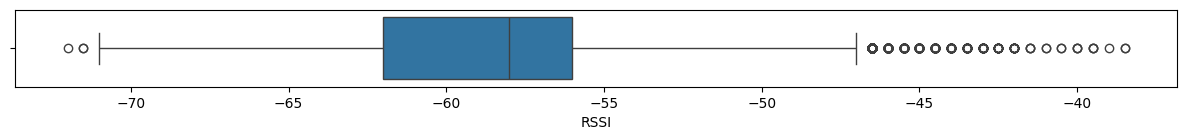

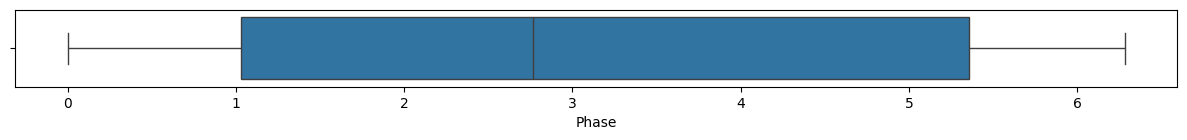

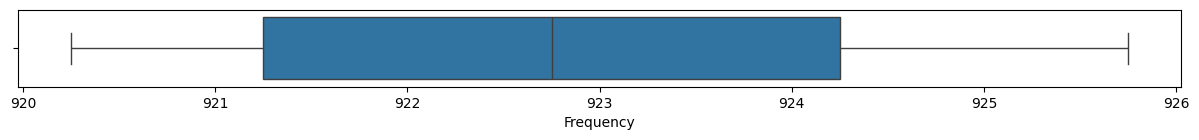

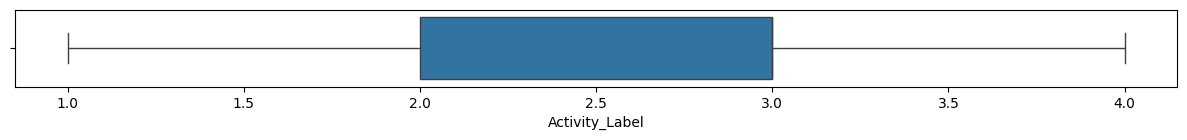

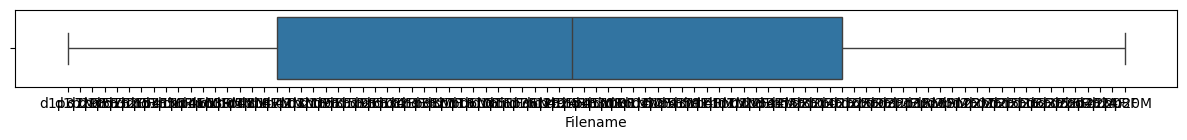

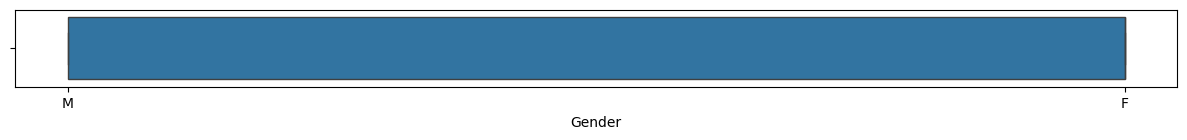

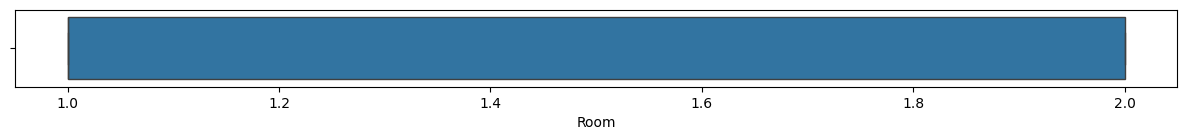

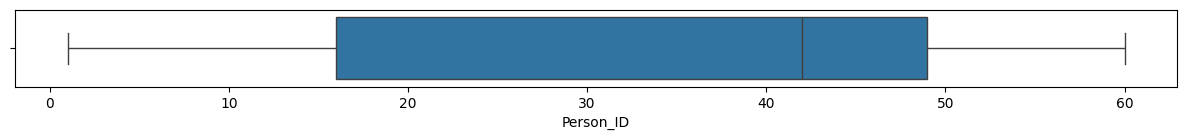

In [29]:
# Anomalies/Outliers
for column in df:
    plt.figure(figsize=(15,1))
    sns.boxplot(data=df, x=column)

In [30]:
# Select only numeric columns
numeric_features = df.select_dtypes(include=['number']).columns

# Detect Outliers using IQR Method
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [31]:
# Count Outliers per feature
outliers = ((df[numeric_features] < lower_bound) | (df[numeric_features] > upper_bound)).sum()
outliers_percent = round(100*outliers/df[numeric_features].count(),1)
outliers_data = pd.concat([outliers, outliers_percent], axis=1, keys=['Total', '%'])
print("\nOutliers Detected per Feature:\n\n",outliers_data)


Outliers Detected per Feature:

                 Total     %
Time             2638   3.5
Frontal_Accel       0   0.0
Vertical_Accel      0   0.0
Lateral_Accel   18796  25.0
Sensor_ID           0   0.0
RSSI              502   0.7
Phase               0   0.0
Frequency           0   0.0
Activity_Label      0   0.0
Room                0   0.0
Person_ID           0   0.0


Time
* 3.5 % of outliers
* As Time have some missing data, Need to analyse graphs weather these are really outliers or not
  
Lateral_Accel
* 25 % of data can never be outlier
* Need more graphical analysis (Histogram & Boxplot)

RSSI
* 0.7 % outliers
* For Confirmation, Need graphical analysis (Histogram & Boxplot)


#### Handling Time Outliers

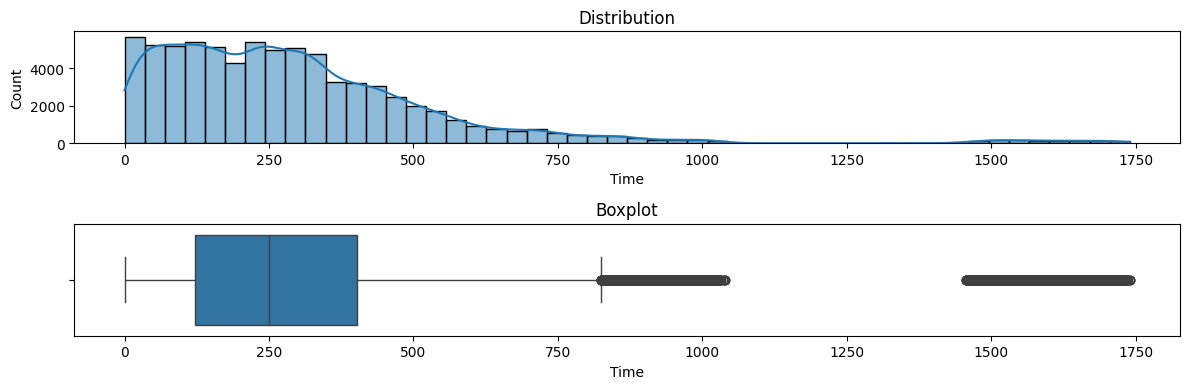

In [33]:
# Distribution of Feature Time
histBox_plot(df,'Time')

Time data is highly Right Skewed

In [34]:
# Skewness calculation
skew_Kurtosis(df,'Time')

Skewness: 2.251576432283377,
Kurtosis: 8.106545153335535


* Skewness 2.25 > 0, It means distribution is Highly Right skewed
* Time distribution having kurtosis > 3, It is leptokurtic (High numbers of outliers)
* It tries to produce more outliers rather than the normal distribution
* Reason :- May be the missing data between range [1050 to 1450], is the reason of high skewness and kurtosis.


More Analysis needed
- Does the missing values are sensor error
- Does the extreme values are genuine values and refer to different activity label or can be treated as anomalies.
- Does trimming and capping the extreme values will have any effect on the models robustness.

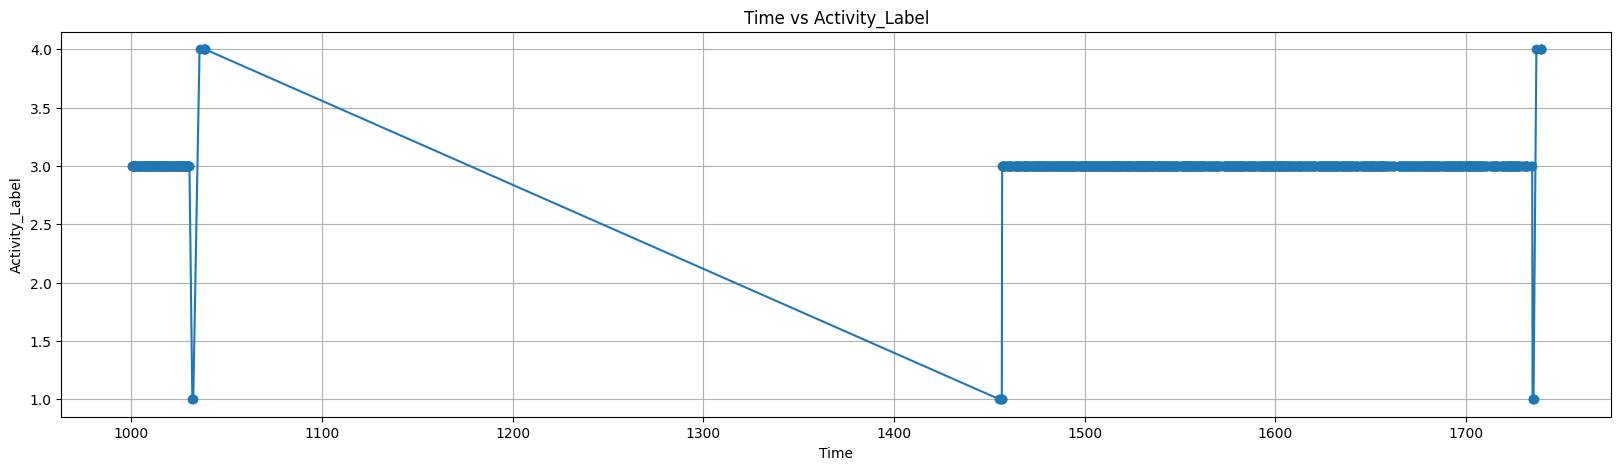

,count
Activity_Label,
3,1304
4,11
1,10


In [35]:
# Zooming into Time values > 1000
df_zoomed = df[df.Time >1000]
plotColXY(df_zoomed,'Time','Activity_Label')

# Proper count of labeling
df_zoomed.Activity_Label.value_counts()

The data is continous, so it might be derived from a same File

In [36]:
df[df.Time >800].Filename.value_counts()

,count
Filename,
d2p02F,1136
d2p14F,1112
d2p17F,456
d2p21M,100
d2p20M,79
d2p26F,9


File Data seems suspecious, Need to examine file data

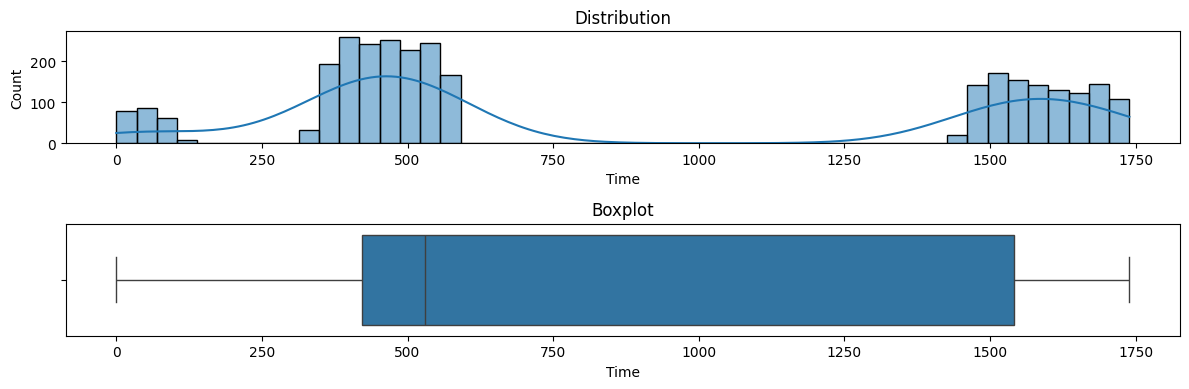

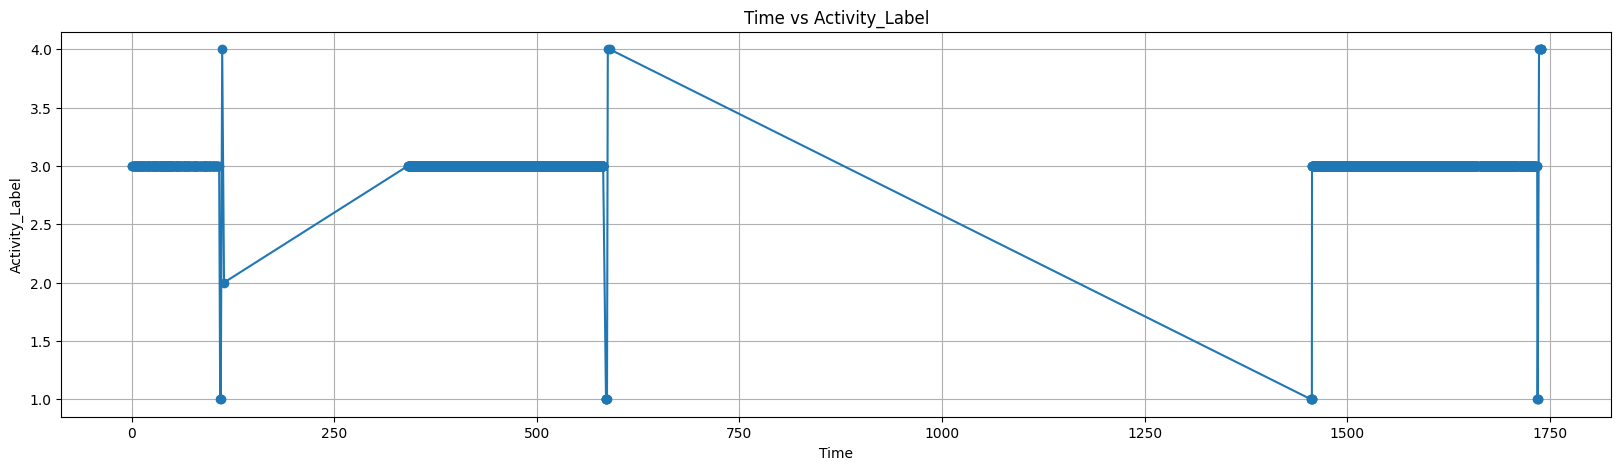

,count
Activity_Label,
3,2967
1,15
4,8
2,1


In [37]:
# Analysing Suspecious File data
suspecious_File = 'd2p02F'
histBox_plot(df[df.Filename==suspecious_File],'Time')
plotColXY(df[df.Filename==suspecious_File],'Time','Activity_Label')
df[df.Filename==suspecious_File].Activity_Label.value_counts()

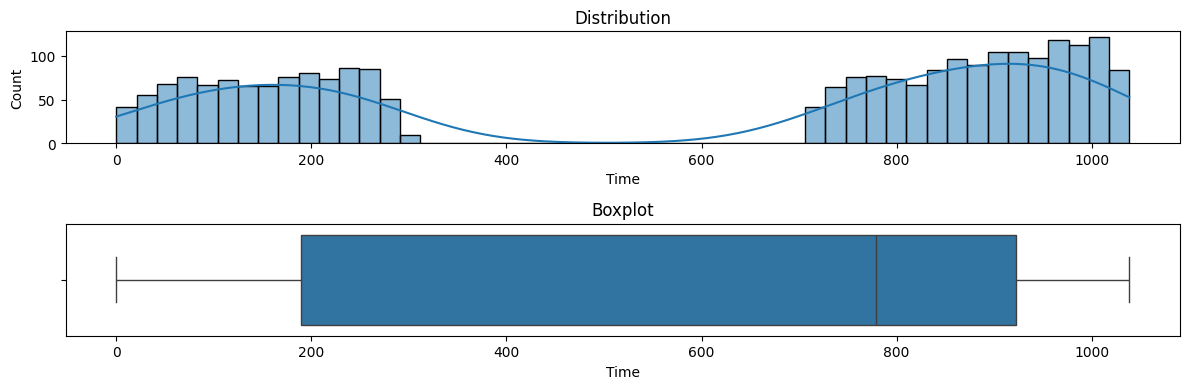

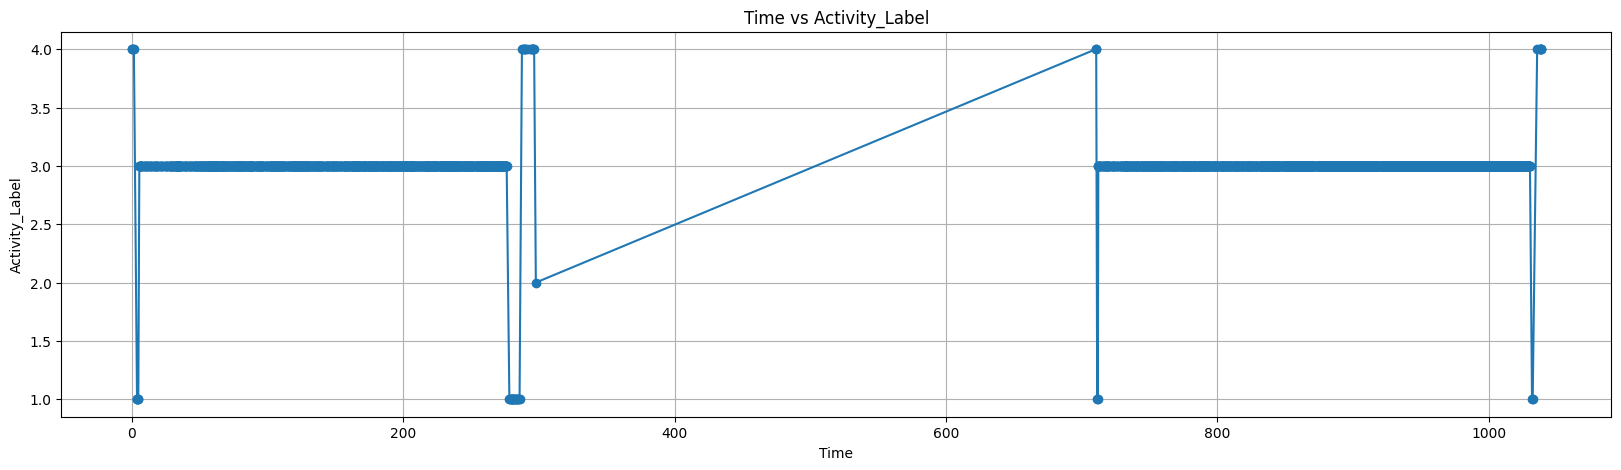

,count
Activity_Label,
3,2328
1,27
4,25
2,1


In [38]:
# Analysing Suspecious File data
suspecious_File = 'd2p14F'
histBox_plot(df[df.Filename==suspecious_File],'Time')
plotColXY(df[df.Filename==suspecious_File],'Time','Activity_Label')
df[df.Filename==suspecious_File].Activity_Label.value_counts()

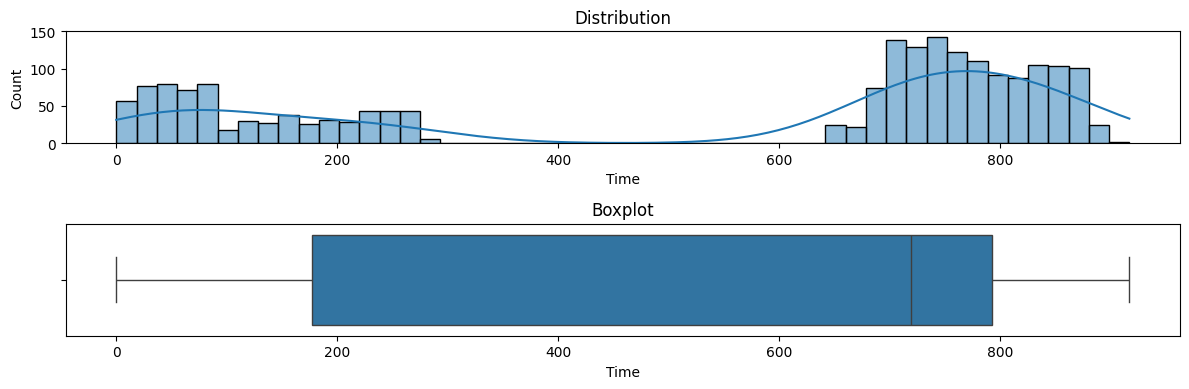

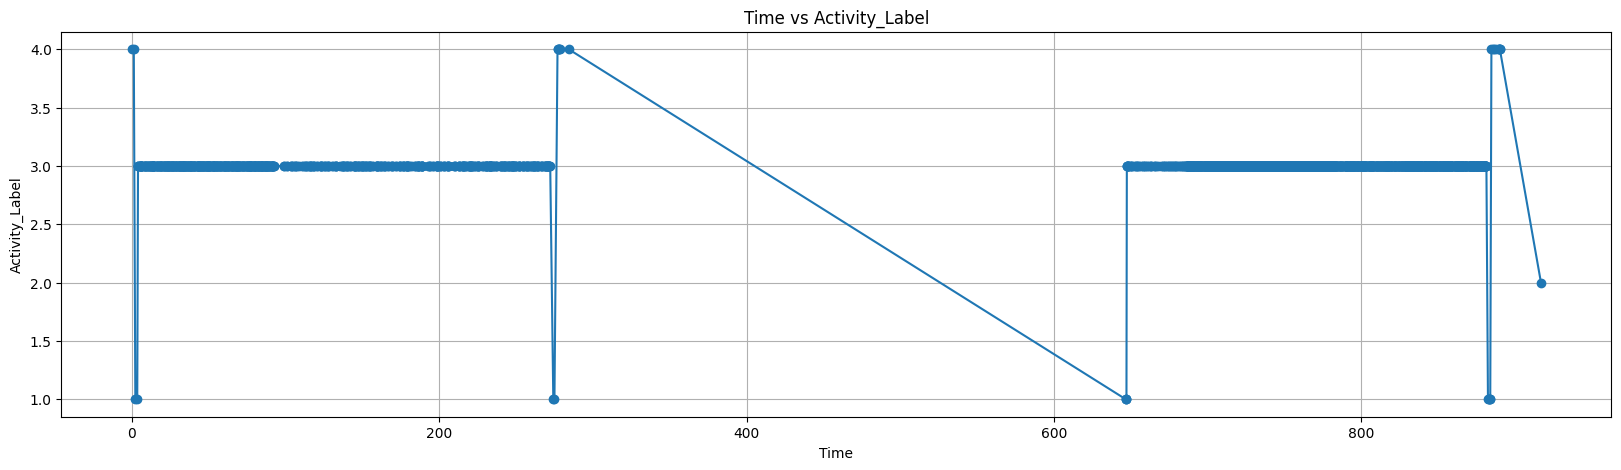

,count
Activity_Label,
3,1946
4,17
1,12
2,1


In [39]:
# Analysing Suspecious File data
suspecious_File = 'd2p17F'
histBox_plot(df[df.Filename==suspecious_File],'Time')
plotColXY(df[df.Filename==suspecious_File],'Time','Activity_Label')
df[df.Filename==suspecious_File].Activity_Label.value_counts()

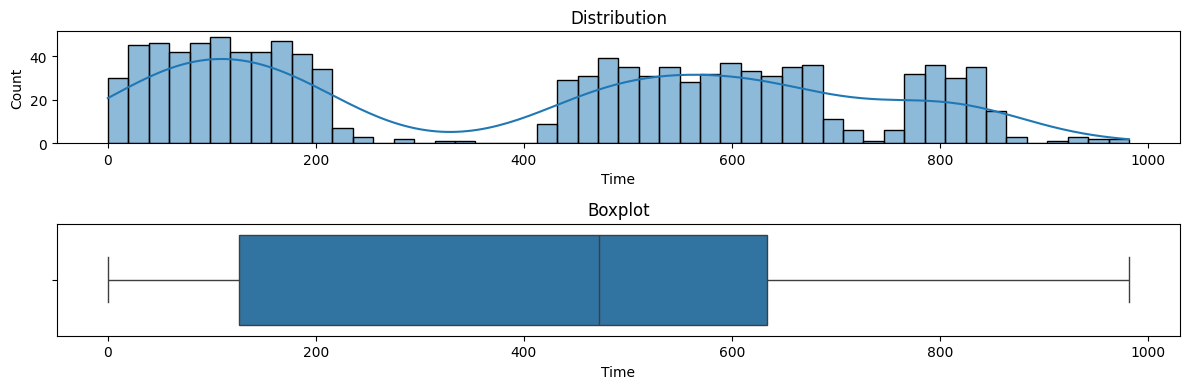

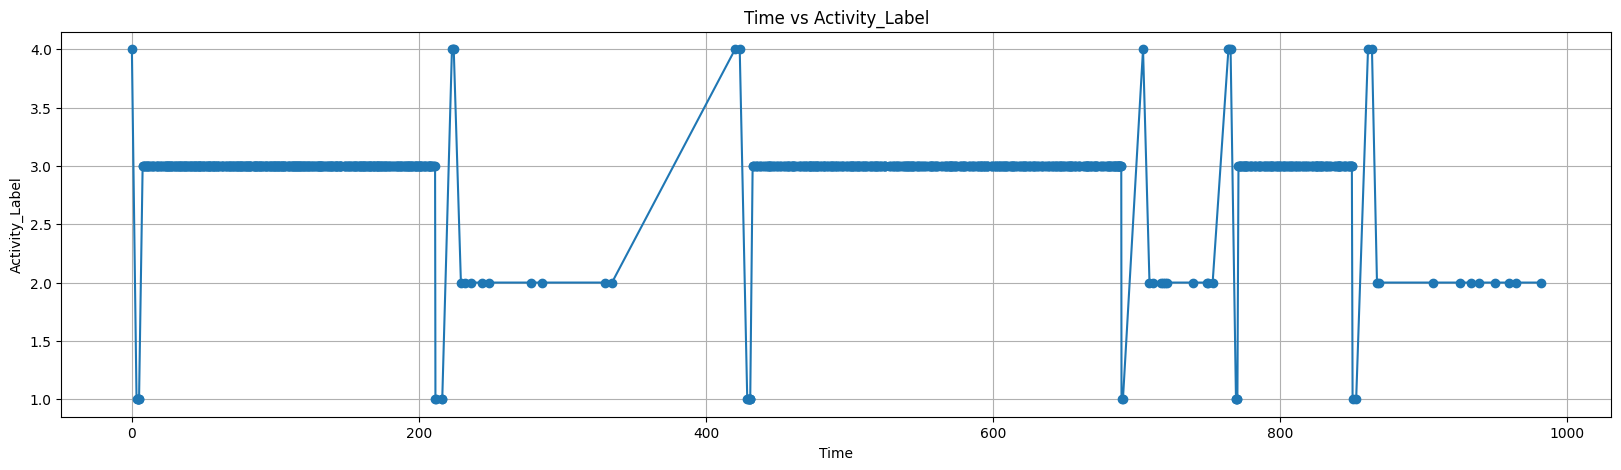

,count
Activity_Label,
3,1036
2,29
1,25
4,12


In [40]:
# Analysing Suspecious File data
suspecious_File = 'd2p21M'
histBox_plot(df[df.Filename==suspecious_File],'Time')
plotColXY(df[df.Filename==suspecious_File],'Time','Activity_Label')
df[df.Filename==suspecious_File].Activity_Label.value_counts()

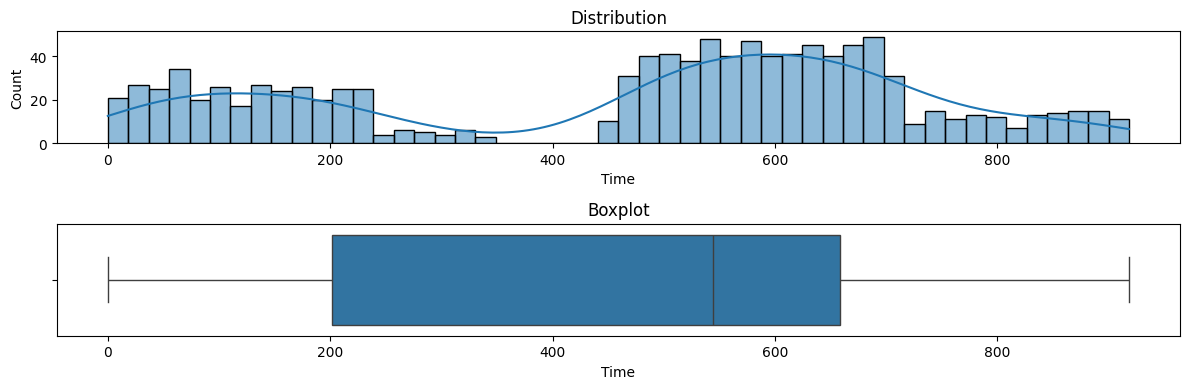

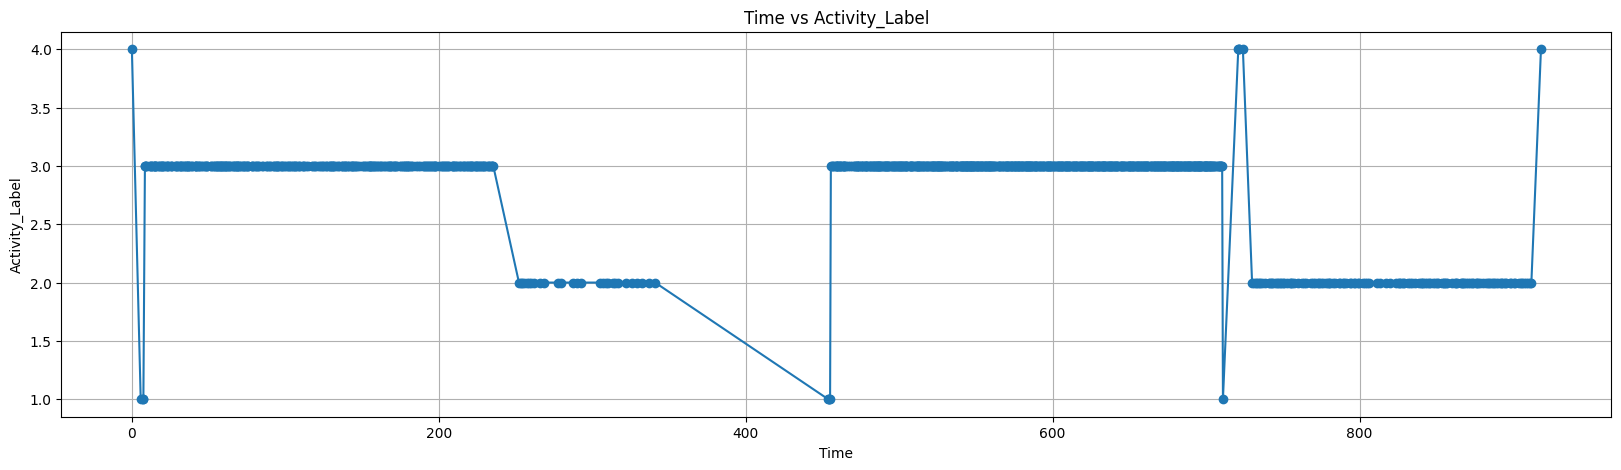

,count
Activity_Label,
3,894
2,158
1,8
4,6


In [41]:
# Analysing Suspecious File data
suspecious_File = 'd2p20M'
histBox_plot(df[df.Filename==suspecious_File],'Time')
plotColXY(df[df.Filename==suspecious_File],'Time','Activity_Label')
df[df.Filename==suspecious_File].Activity_Label.value_counts()

**First insight**

Time values above 1000 can be considered as anomalies, because most of the data refers to the same Activtiy Label and doesn't contribute much to the classification.
- Trimming Time values above 1000 can be the solution because Capping the values will increase the model complexity & will only result in poor classification.

**Second Insight**
After further examining the suspecious file data, The File data clearly seems errorneous (may be due to sensor failure or any other reason). Also the remaining collected data above 800 i.e. (Time>800) in File doesn't contribute much to the classification
- Trimming the [d2p02F, d2p14F, d2p17F] file data over Time > 800 will be good to remove these anomalies

In [42]:
# Trimming (Deleting rows with time >1000)
#df=df[df.Time<=1000]
df=df[~((df.Filename.isin(['d2p02F', 'd2p14F', 'd2p17F'])) & (df.Time>800))]

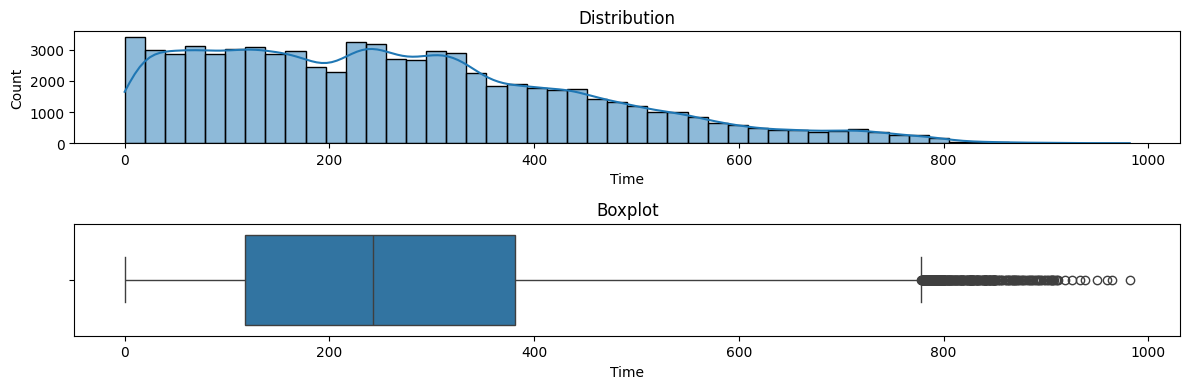

In [43]:
# Again Anlysing after removing outliers
histBox_plot(df,'Time')

#### Handling Lateral Acceleration Outliers

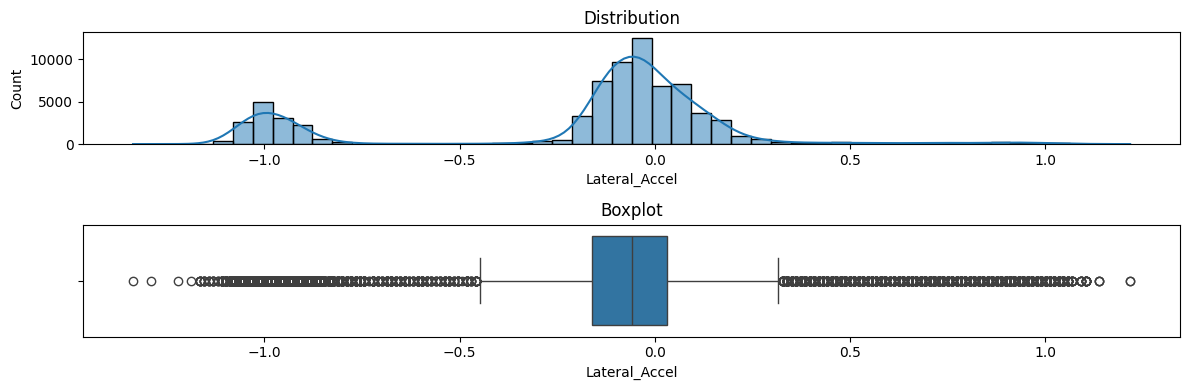

In [44]:
histBox_plot(df,'Lateral_Accel')

    Distribution is bimodal

In [45]:
# Measuring Skewness and Kurtosis
skew_Kurtosis(df,'Lateral_Accel')

Skewness: -0.8900029948830315,
Kurtosis: 0.39323568626481675


```
Negative kurtosis means that distribution is platykurtic.
- most of the data is concentrated near the mean


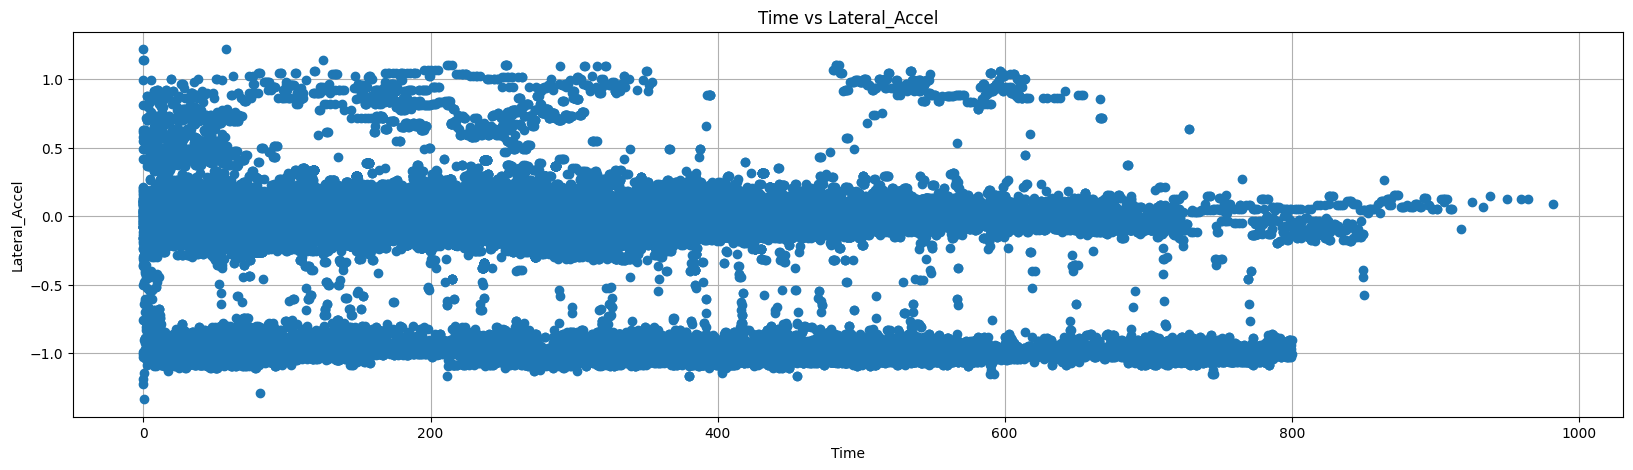

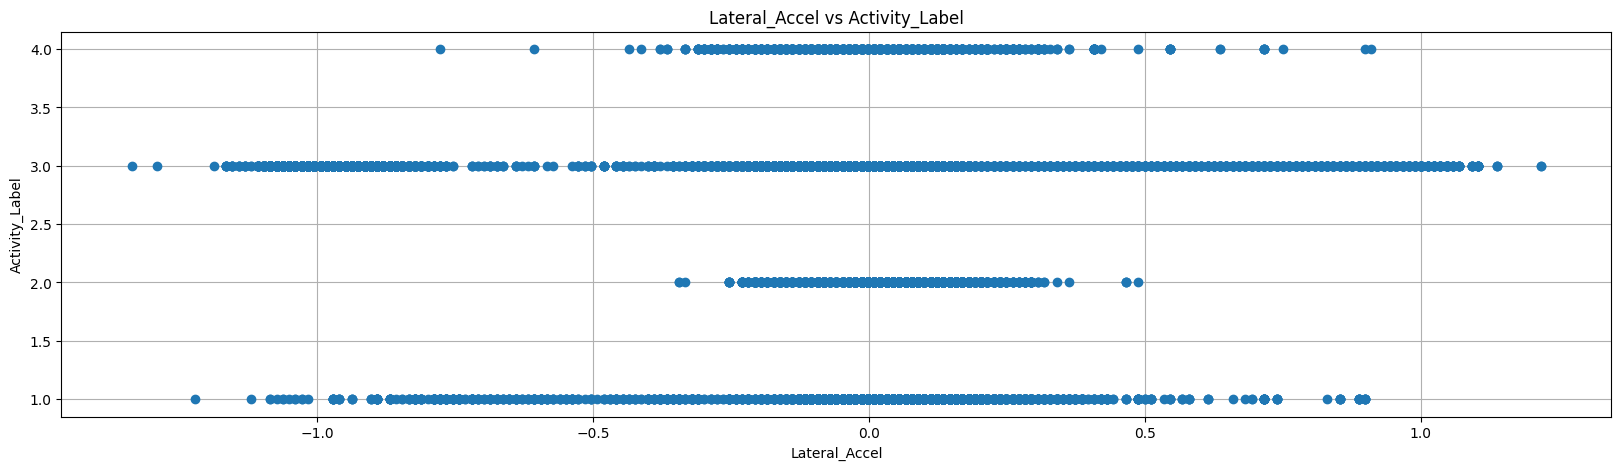

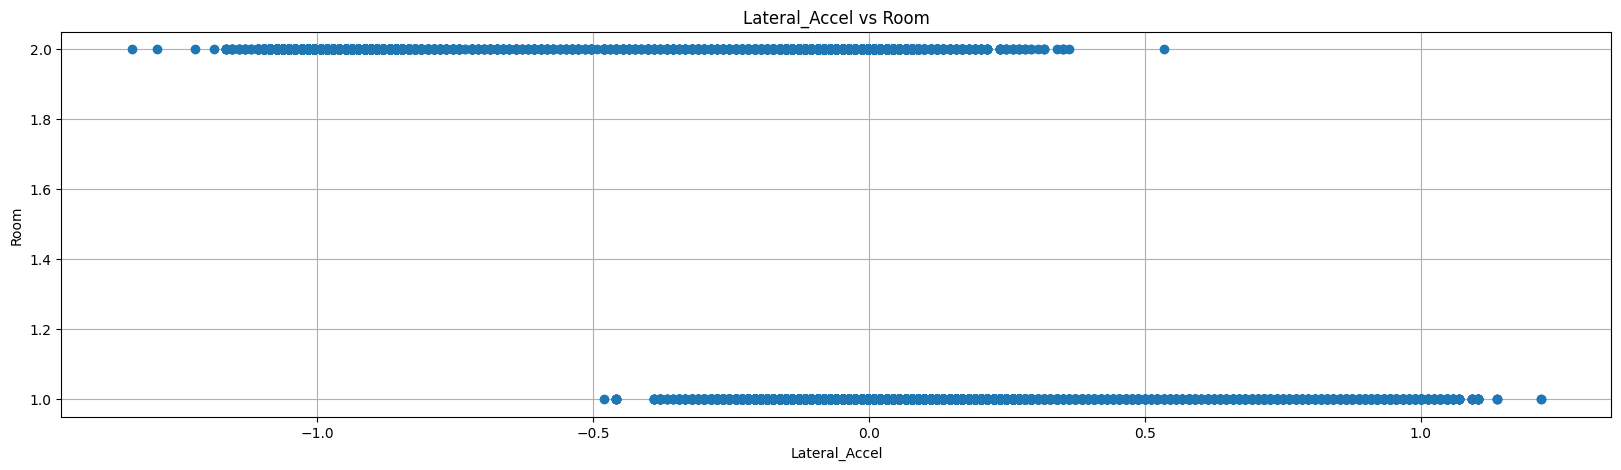

In [46]:
plotColXY(df,'Time','Lateral_Accel',line='')
plotColXY(df,'Lateral_Accel','Activity_Label',line='')
plotColXY(df,'Lateral_Accel','Room',line='')

```
The Lateral Accelaration is corelated with the room number.
(Reason for Bimodal distribution)
- The Lateral acceleration depends on where the chair and bed is located in the room
- Means that the position of the chair and bed is different in both rooms

(Bimodal distribution and platykurtis is reason for high number of calculated outliers in IQR method)
- Outliers in IQR calculation of Laetral_Accel are genuine values not outliers.



The values are genuine and can be capped to [-1.0, 1.0] for reducing Extreme values

In [47]:
df.Lateral_Accel = df.Lateral_Accel.clip(-1,1)
print(f'Max : {df.Lateral_Accel.max()} \nMin : {df.Lateral_Accel.min()}')

Max : 1.0 
Min : -1.0


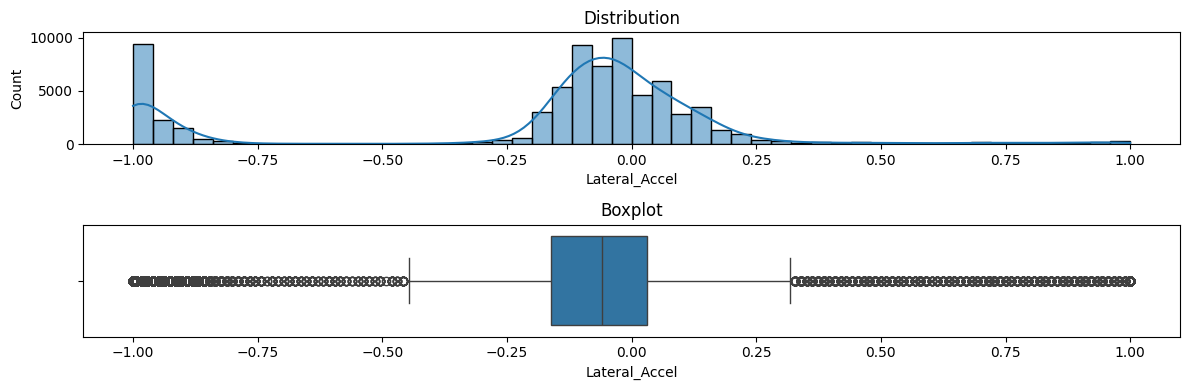

In [48]:
histBox_plot(df,'Lateral_Accel')

#### Handling RSSI (Received signal strength indicator) Outliers

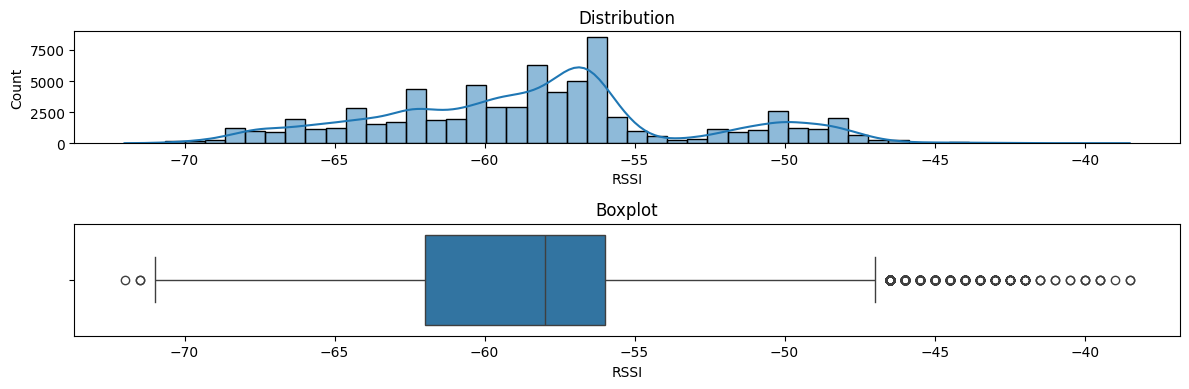

In [49]:
histBox_plot(df,'RSSI')

In [50]:
# Measuring Skewness and Kurtosis
skew_Kurtosis(df,'RSSI')

Skewness: 0.241163002268278,
Kurtosis: -0.19226386867144685


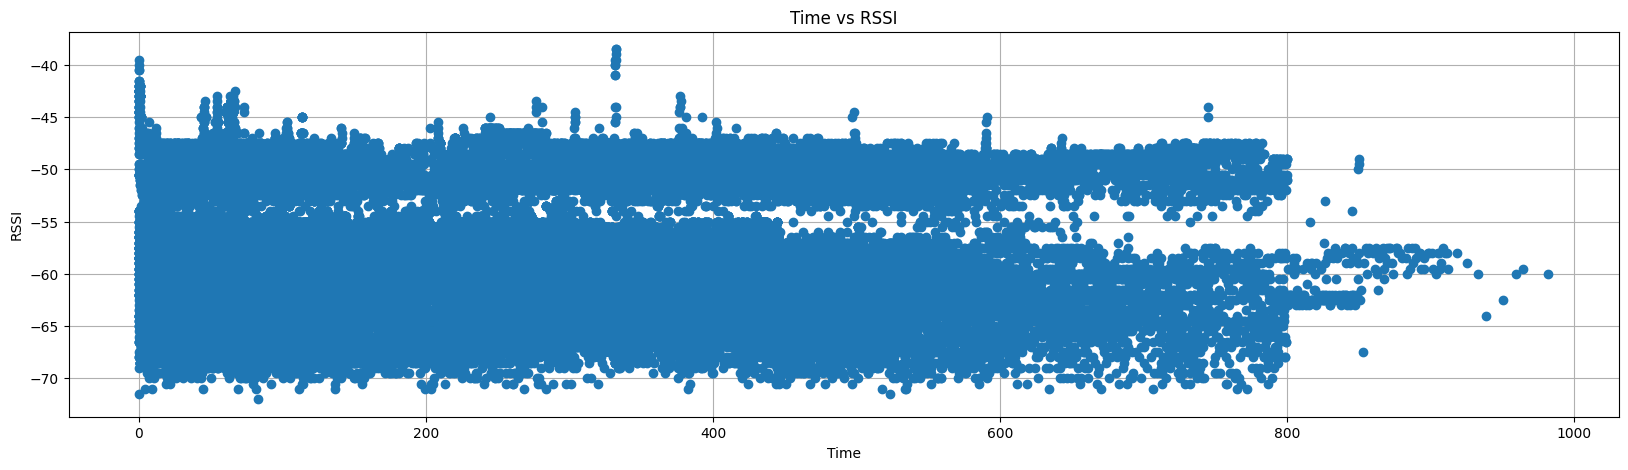

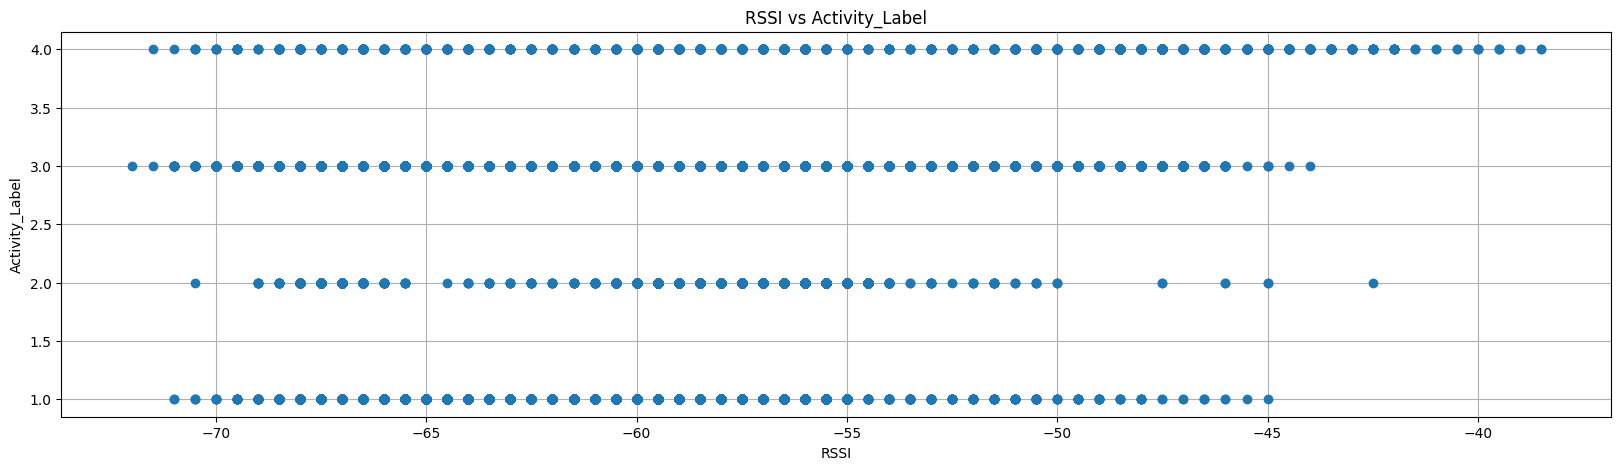

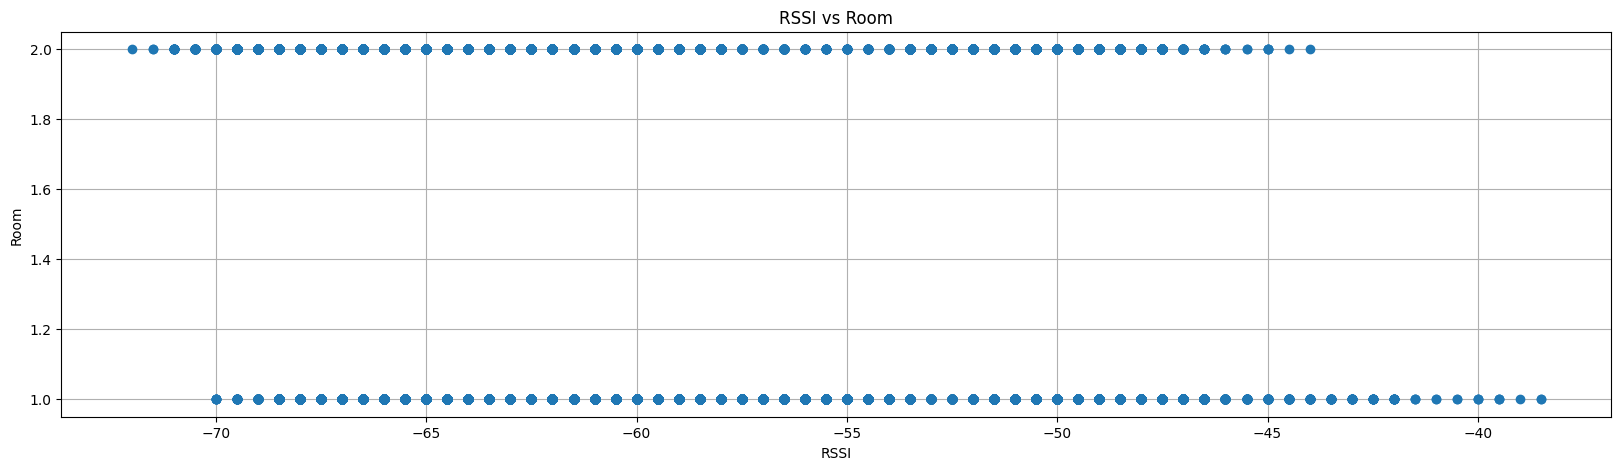

In [51]:
plotColXY(df,'Time','RSSI',line='')
plotColXY(df,'RSSI','Activity_Label',line='')
plotColXY(df,'RSSI','Room',line='')

```
The RSSI is correlated with the location of room and position of Chair and Bed.
 (platykurtis is reason for high number of calculated outliers in IQR method)
- Outliers in IQR calculation of RSSI are genuine values not outliers and will be helpful in better model prediction


### Feature Engineering

In [53]:
df.head()

,Time,Frontal_Accel,Vertical_Accel,Lateral_Accel,Sensor_ID,RSSI,Phase,Frequency,Activity_Label,Filename,Gender,Room,Person_ID
0,0.000,0.31893,0.99674,0.088944,4,-57.5,1.50020,924.75,1,d1p37M,M,1,37
1,0.025,0.31893,0.99674,0.088944,1,-56.5,5.15420,924.25,1,d1p37M,M,1,37
2,0.250,0.31893,0.99674,0.088944,4,-58.5,5.71710,924.25,1,d1p37M,M,1,37
3,0.500,0.31893,0.99674,0.088944,1,-57.0,5.59140,920.75,1,d1p37M,M,1,37
4,0.550,0.31893,0.99674,0.088944,1,-57.5,0.22089,923.25,1,d1p37M,M,1,37


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72422 entries, 0 to 75127
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Time            72422 non-null  float64
 1   Frontal_Accel   72422 non-null  float64
 2   Vertical_Accel  72422 non-null  float64
 3   Lateral_Accel   72422 non-null  float64
 4   Sensor_ID       72422 non-null  int64  
 5   RSSI            72422 non-null  float64
 6   Phase           72422 non-null  float64
 7   Frequency       72422 non-null  float64
 8   Activity_Label  72422 non-null  int64  
 9   Filename        72422 non-null  object 
 10  Gender          72422 non-null  object 
 11  Room            72422 non-null  int64  
 12  Person_ID       72422 non-null  int64  
dtypes: float64(7), int64(4), object(2)
memory usage: 7.7+ MB


In [55]:
df.Sensor_ID.value_counts()

,count
Sensor_ID,
3,23285
1,22324
4,14200
2,12613


Converting Sensor_ID, Activity_Label, Gender, Room, Person ID to categorical data

In [56]:
'''
df.Activity_Label =  df.Activity_Label.map({1: "Sit on Bed", 2: "Sit on Chair", 3: "Lying", 4: "Ambulating"})
df.Sensor_ID = 'Sensor' + df.Sensor_ID.astype(str)
df.Room = 'Room' + df.Room.astype(str)
'''

'\ndf.Activity_Label =  df.Activity_Label.map({1: "Sit on Bed", 2: "Sit on Chair", 3: "Lying", 4: "Ambulating"})\ndf.Sensor_ID = \'Sensor\' + df.Sensor_ID.astype(str)\ndf.Room = \'Room\' + df.Room.astype(str)\n'

In [57]:
df.head()

,Time,Frontal_Accel,Vertical_Accel,Lateral_Accel,Sensor_ID,RSSI,Phase,Frequency,Activity_Label,Filename,Gender,Room,Person_ID
0,0.000,0.31893,0.99674,0.088944,4,-57.5,1.50020,924.75,1,d1p37M,M,1,37
1,0.025,0.31893,0.99674,0.088944,1,-56.5,5.15420,924.25,1,d1p37M,M,1,37
2,0.250,0.31893,0.99674,0.088944,4,-58.5,5.71710,924.25,1,d1p37M,M,1,37
3,0.500,0.31893,0.99674,0.088944,1,-57.0,5.59140,920.75,1,d1p37M,M,1,37
4,0.550,0.31893,0.99674,0.088944,1,-57.5,0.22089,923.25,1,d1p37M,M,1,37


#### Balancing Dataset

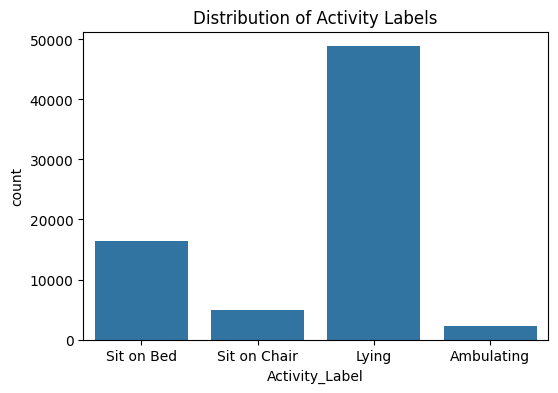

In [58]:
# Visualize Dataset Distribution

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=df['Activity_Label'])
plt.xticks(ticks=[0,1,2,3], labels=['Sit on Bed', 'Sit on Chair', 'Lying', 'Ambulating'])
plt.title('Distribution of Activity Labels')
plt.show()



 New Class Distribution:
Activity_Label
1    2271
2    2271
3    2271
4    2271
Name: count, dtype: int64


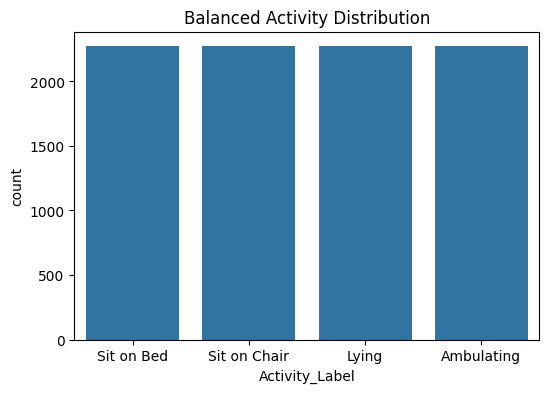

In [59]:
from imblearn.under_sampling import RandomUnderSampler

# Define features (X) and labels (y)
X = df.drop(columns=["Activity_Label", "Filename"])
y = df['Activity_Label']

# Apply Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# Convert back to DataFrame
df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced["Activity_Label"] = y_resampled

# Verify new class distribution
print("\n New Class Distribution:")
print(df_balanced["Activity_Label"].value_counts())

# Plot new distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df_balanced["Activity_Label"])
plt.xticks(ticks=[0,1,2,3], labels=["Sit on Bed", "Sit on Chair", "Lying", "Ambulating"])
plt.title("Balanced Activity Distribution")
plt.show()

In [60]:
df_balanced.shape

(9084, 12)

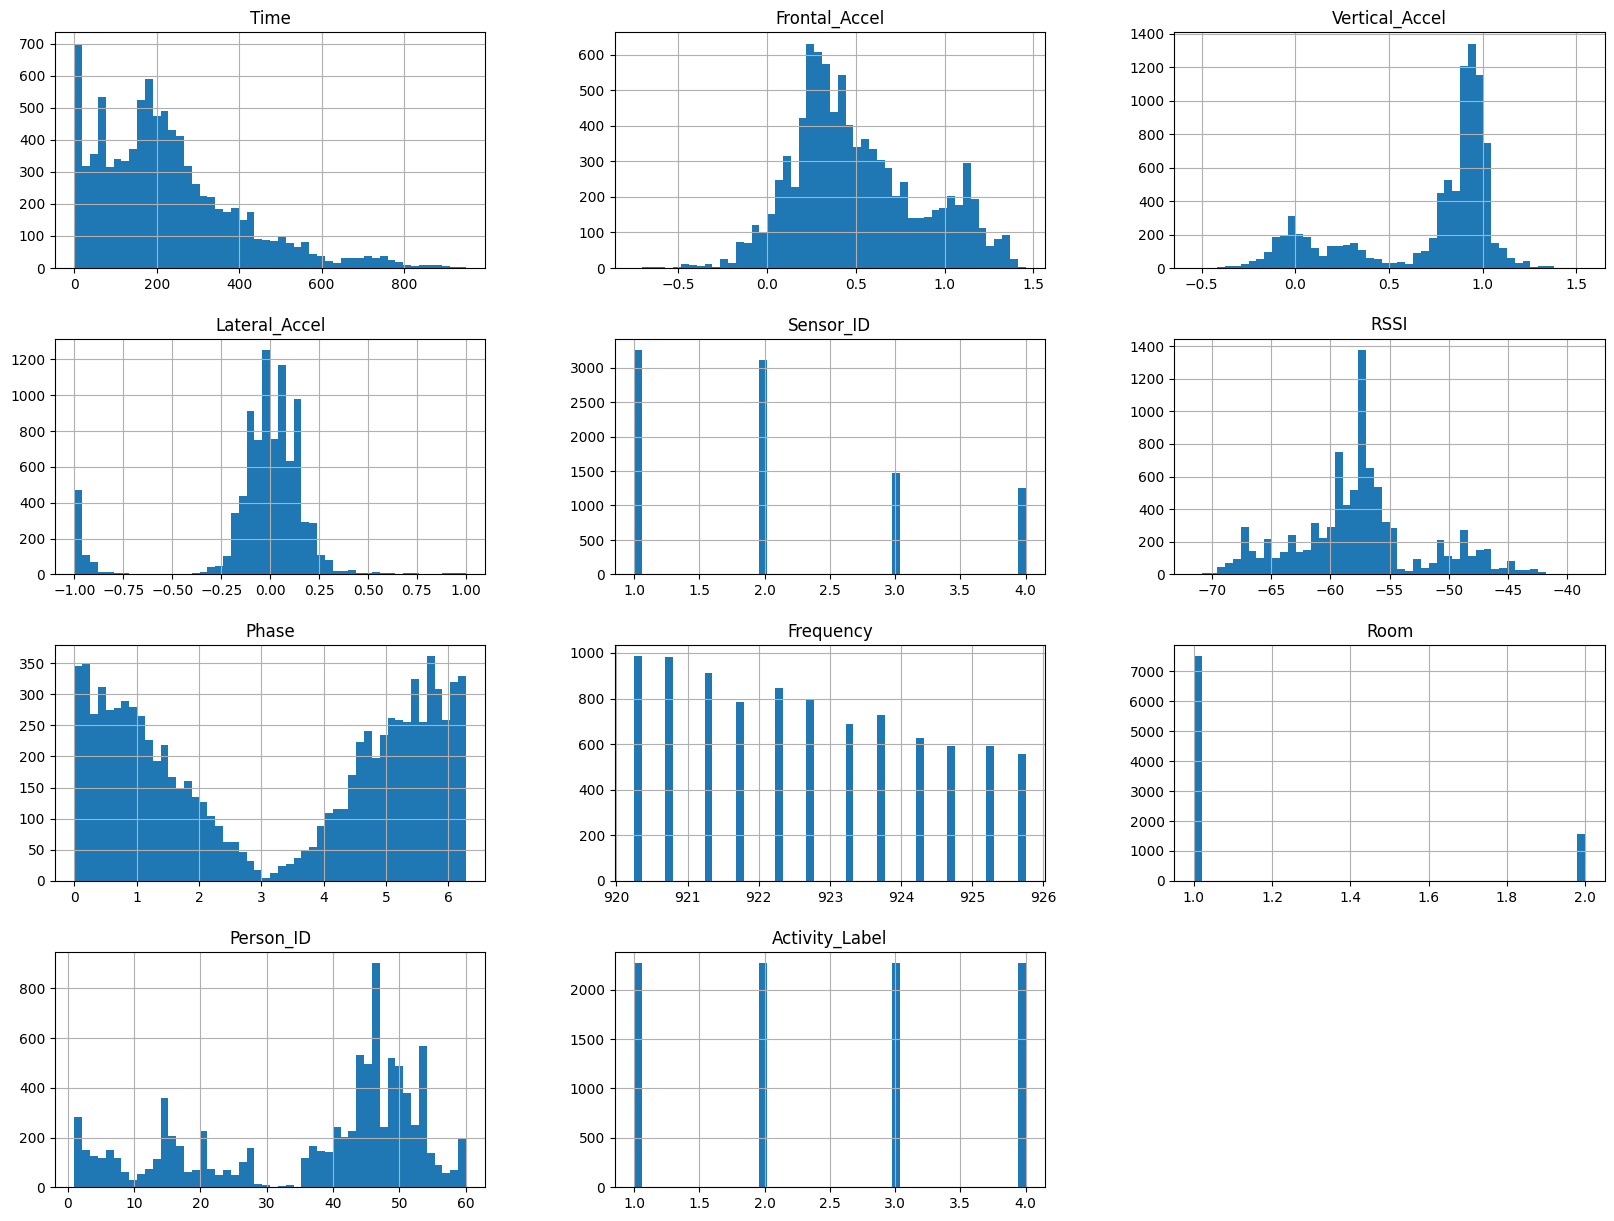

In [61]:
# Distribution of Column data
df_balanced.hist(figsize=(20,15),bins=50)
plt.show()

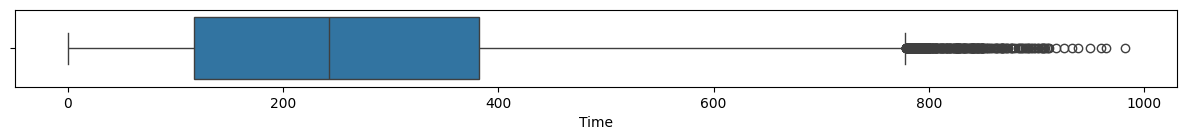

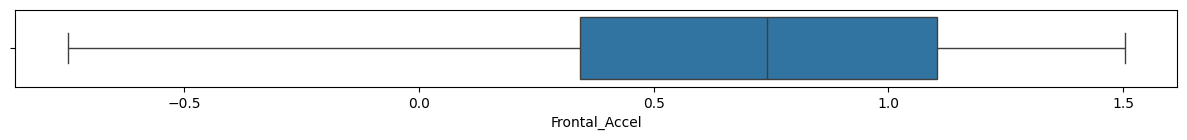

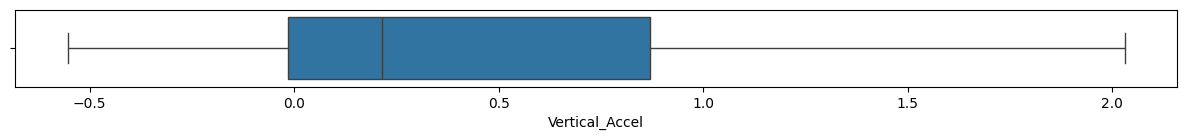

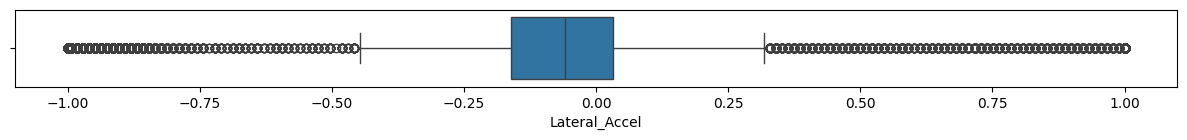

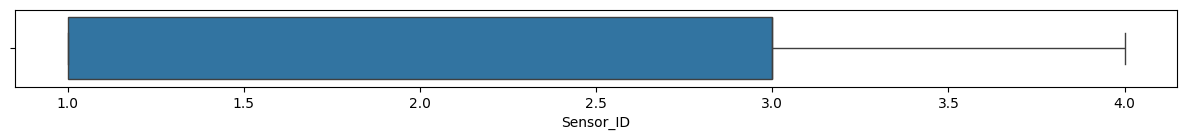

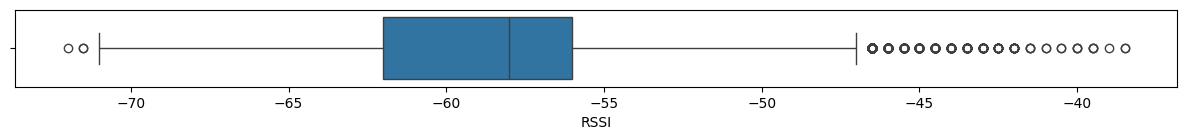

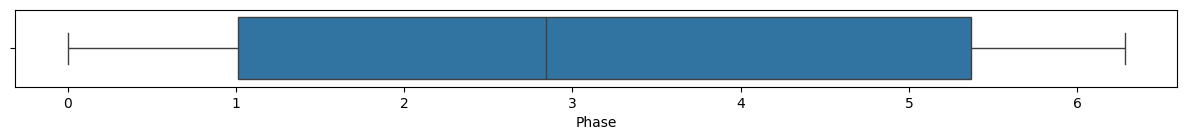

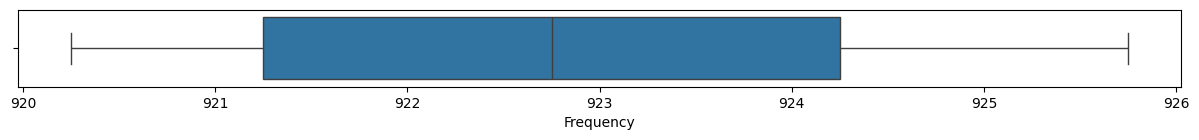

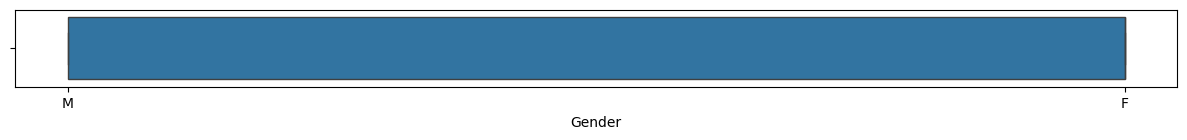

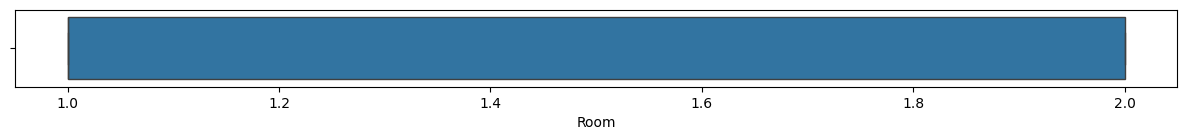

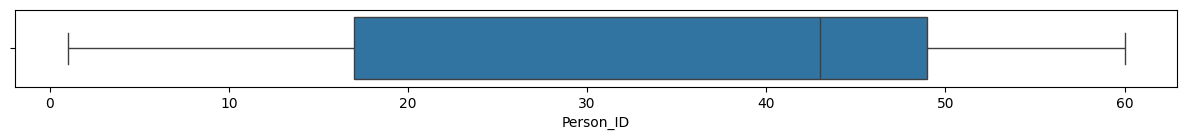

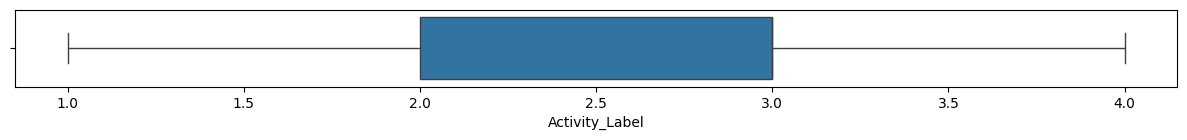

In [62]:
# Anomalies/Outliers
for column in df_balanced :
    plt.figure(figsize=(15,1))
    sns.boxplot(data=df, x=column)

In [63]:
df_balanced.to_csv('data/processed/df_balanced')

## Model

#### Creating Training & Testing Data

In [64]:
from sklearn.model_selection import train_test_split

# Important features and Labelled features
#imp_features =df_balanced.columns.remove(['Activity_Label','Filename'])
label = 'Activity_Label'

# Define features(X) and target (y)
X = df_balanced.drop(columns=['Activity_Label'])
y = df_balanced.Activity_Label

# Apply Train-Test Split (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Confirm split
print(f"Training Set: {X_train.shape}, Test Set: {X_test.shape}")

Training Set: (7267, 11), Test Set: (1817, 11)


In [65]:
# Check distribution of Activity_Label in train and test sets
print("Training Set Activity_Label Distribution\n", y_train.value_counts(normalize=True))
print("\nTest Set Acitivity_Label Distribution", y_test.value_counts(normalize=True))

Training Set Activity_Label Distribution
 Activity_Label
4    0.250034
2    0.250034
1    0.250034
3    0.249897
Name: proportion, dtype: float64

Test Set Acitivity_Label Distribution Activity_Label
3    0.250413
2    0.249862
1    0.249862
4    0.249862
Name: proportion, dtype: float64


Evaluation Metrics

In [66]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,classification_report,multilabel_confusion_matrix

def performance(model,X_test,y_test) :
  y_pred = model.predict(X_test)

  print("\nClassification Report:\n", classification_report(y_test, y_pred))
  print('Accuracy = ', accuracy_score(y_test, y_pred))
  print('Precision = ', precision_score(y_test, y_pred, average='macro'))
  print('Recall = ', recall_score(y_test, y_pred, average='macro'))
  print('F1 Score =', f1_score(y_test, y_pred, average='macro'))

In [67]:
# Function to plot confusion matrix
def plot_confusion_matrix(cm, labels):
    fig, axes = plt.subplots(1, len(labels), figsize=(15, 3))
    for i, ax in enumerate(axes):
        sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f'Label {labels[i]}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()

### Pipelining Process

Next Steps:<br>
Proceed with Model Selection & Baseline Creation:<br>
1. Try Simple Models First (Decision Tree, Decision forest, Random Forest, AdaBoost)<br>
2. Evaluate Performance (Accuracy, Precision, Recall, F1-Score)<br>
3. Baseline Comparision.

In [68]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,classification_report,multilabel_confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [69]:
from sklearn.base import BaseEstimator, TransformerMixin

In [70]:
# Numerical and Categorical features
num_features = [feature for feature in X_train.columns if X_train[feature].dtype=='int64' or X_train[feature].dtype=='float64']
cat_features = [feature for feature in X_train.columns if X_train[feature].dtype=='object']


num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
    ])


pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Time', 'Frontal_Accel',
                                                   'Vertical_Accel',
                                                   'Lateral_Accel', 'Sensor_ID',
                                                   'RSSI', 'Phase', 'Frequency',
                                                   'Room', 'Person_ID']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['Gender'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

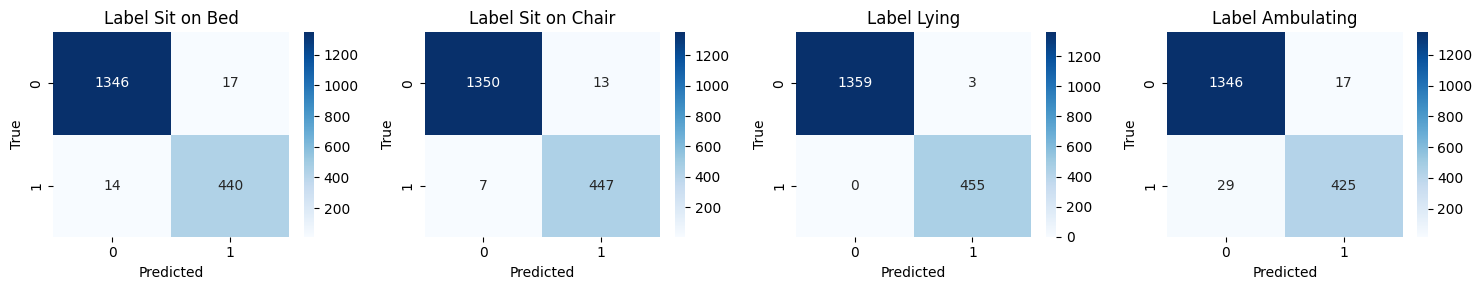

In [71]:
y_pred = pipeline.predict(X_test)
mcm=multilabel_confusion_matrix(y_test, y_pred)

labels = ["Sit on Bed",  "Sit on Chair",  "Lying", "Ambulating"]
plot_confusion_matrix(mcm, labels)

In [72]:
performance(pipeline,X_test,y_test)


Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.97      0.97       454
           2       0.97      0.98      0.98       454
           3       0.99      1.00      1.00       455
           4       0.96      0.94      0.95       454

    accuracy                           0.97      1817
   macro avg       0.97      0.97      0.97      1817
weighted avg       0.97      0.97      0.97      1817

Accuracy =  0.972482113373693
Precision =  0.972382062226539
Recall =  0.972466960352423
F1 Score = 0.9723661163474261


### Using Different Models

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,classification_report,multilabel_confusion_matrix

In [74]:
imp_Cols=['Frontal_Accel', 'Vertical_Accel', 'Lateral_Accel', 'Sensor_ID','RSSI', 'Phase', 'Frequency', 'Gender', 'Room']
labeled_feature = 'Activity_Label'

#df_balanced = pd.read_csv('data/processed/df_balanced.csv')
labels = ["Sit on Bed",  "Sit on Chair",  "Lying", "Ambulating"]

In [75]:
def train_model(classifier,imp_Cols=imp_Cols,labeled_feature=labeled_feature,labels=labels):
  # Define features(X) and target (y)
  X = df_balanced[imp_Cols]
  y = df_balanced[labeled_feature]

  # Apply Train-Test Split (80-20 split)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

  # Numerical and Categorical features
  num_features = [feature for feature in X_train.columns if X_train[feature].dtype=='int64' or X_train[feature].dtype=='float64']
  cat_features = [feature for feature in X_train.columns if X_train[feature].dtype=='object']


  num_pipeline = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='mean')),
      ('scaler', StandardScaler())
  ])

  cat_pipeline = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('encoder', OneHotEncoder())
  ])

  preprocessor = ColumnTransformer(
      transformers=[
          ('num', num_pipeline, num_features),
          ('cat', cat_pipeline, cat_features)
      ])


  pipeline = Pipeline(steps=[
      ('preprocessor',preprocessor),
      ('classifier',classifier)
  ])

  pipeline.fit(X_train,y_train)
  y_pred = pipeline.predict(X_test)

  mcm=multilabel_confusion_matrix(y_test, y_pred)
  plot_confusion_matrix(mcm, labels)

  performance(pipeline,X_test,y_test)

  return pipeline

#### Decision Tree



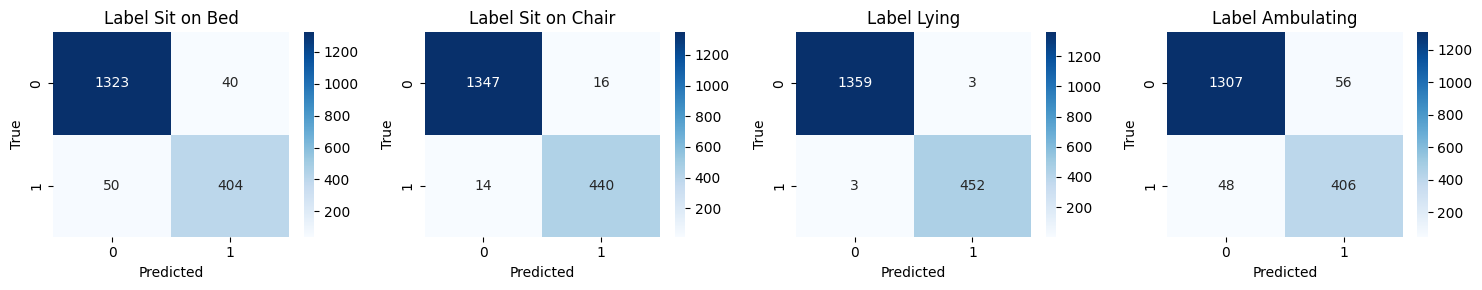


Classification Report:
               precision    recall  f1-score   support

           1       0.91      0.89      0.90       454
           2       0.96      0.97      0.97       454
           3       0.99      0.99      0.99       455
           4       0.88      0.89      0.89       454

    accuracy                           0.94      1817
   macro avg       0.94      0.94      0.94      1817
weighted avg       0.94      0.94      0.94      1817

Accuracy =  0.9367088607594937
Precision =  0.9367541657015341
Recall =  0.9366776395410756
F1 Score = 0.9366699313466025


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Frontal_Accel',
                                                   'Vertical_Accel',
                                                   'Lateral_Accel', 'Sensor_ID',
                                                   'RSSI', 'Phase', 'Frequency',
                                                   'Room']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['Gender'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [76]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=42)
#Training and evaluating model
train_model(classifier)

#### Random Forest



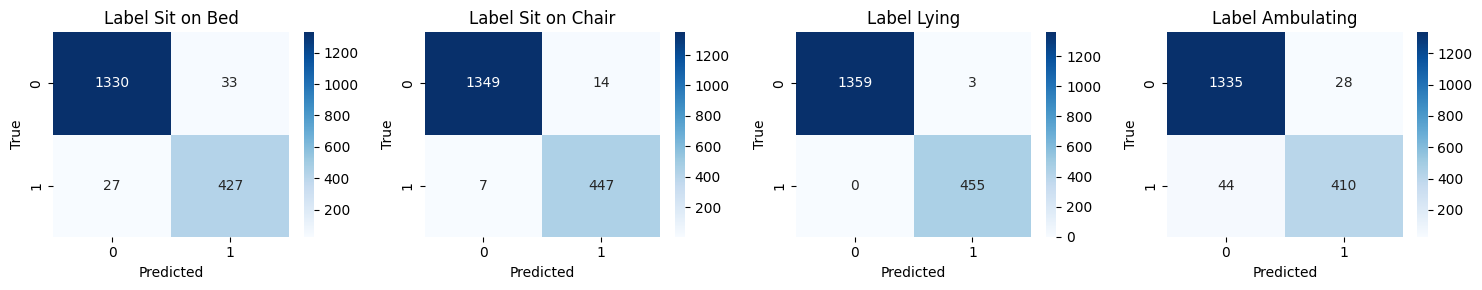


Classification Report:
               precision    recall  f1-score   support

           1       0.93      0.94      0.93       454
           2       0.97      0.98      0.98       454
           3       0.99      1.00      1.00       455
           4       0.94      0.90      0.92       454

    accuracy                           0.96      1817
   macro avg       0.96      0.96      0.96      1817
weighted avg       0.96      0.96      0.96      1817

Accuracy =  0.9570720968629609
Precision =  0.9568537367569632
Recall =  0.9570484581497798
F1 Score = 0.9568500766399215


In [77]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=100, random_state=42)

#Training and evaluating model
RF_model = train_model(classifier)

#### AdaBoostClassifier



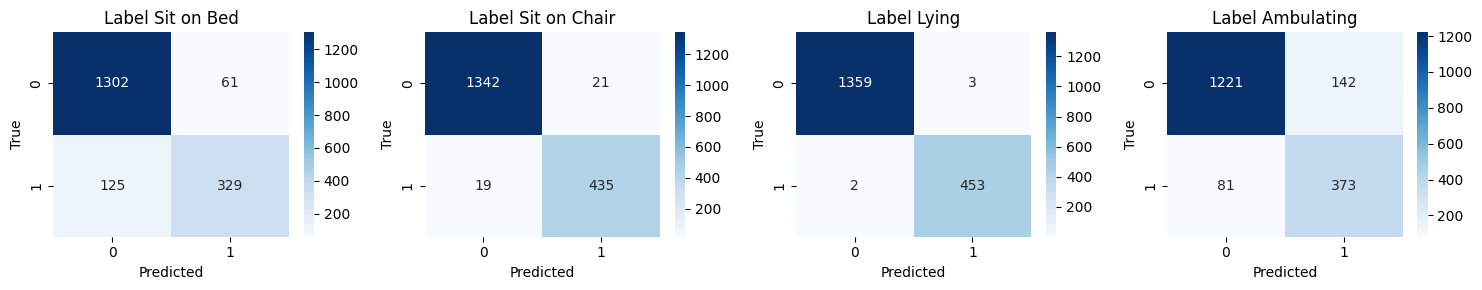


Classification Report:
               precision    recall  f1-score   support

           1       0.84      0.72      0.78       454
           2       0.95      0.96      0.96       454
           3       0.99      1.00      0.99       455
           4       0.72      0.82      0.77       454

    accuracy                           0.88      1817
   macro avg       0.88      0.88      0.88      1817
weighted avg       0.88      0.88      0.88      1817

Accuracy =  0.8750687947165657
Precision =  0.8788075023256423
Recall =  0.875002420487002
F1 Score = 0.8750105439984063


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Frontal_Accel',
                                                   'Vertical_Accel',
                                                   'Lateral_Accel', 'Sensor_ID',
                                                   'RSSI', 'Phase', 'Frequency',
                                                   'Room']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['Gender'])])),
                ('classifier',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                                     random_state=42),
                                    random_state=42))])

In [78]:
from sklearn.ensemble import AdaBoostClassifier

# Base model: Decision Tree (shallow depth) - without Pipeline
base_learner = DecisionTreeClassifier(max_depth=5, random_state=42)

# AdaBoost Classifier
classifier = AdaBoostClassifier(estimator=base_learner, n_estimators=50, learning_rate=1.0, random_state=42)

#Training and evaluating model
train_model(classifier)

#### Gradient Boosting Classifier



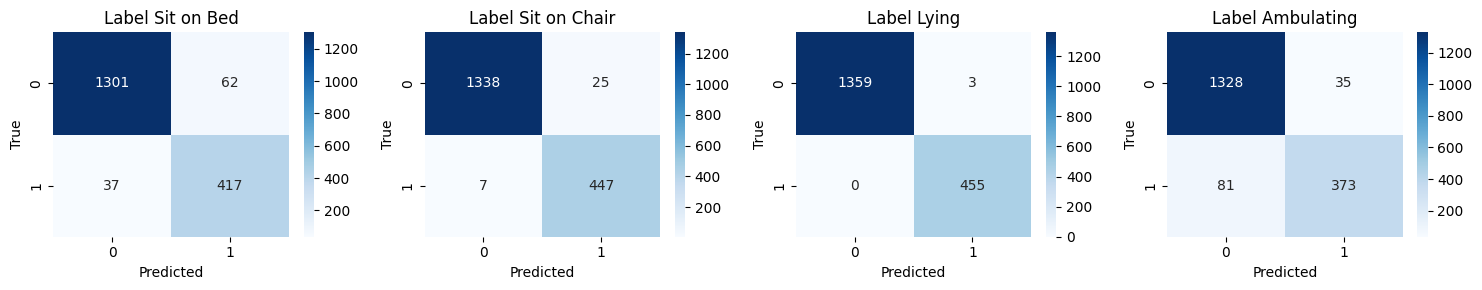


Classification Report:
               precision    recall  f1-score   support

           1       0.87      0.92      0.89       454
           2       0.95      0.98      0.97       454
           3       0.99      1.00      1.00       455
           4       0.91      0.82      0.87       454

    accuracy                           0.93      1817
   macro avg       0.93      0.93      0.93      1817
weighted avg       0.93      0.93      0.93      1817

Accuracy =  0.9312052834342323
Precision =  0.9313157601401216
Recall =  0.9311674008810573
F1 Score = 0.9303692008507469


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Frontal_Accel',
                                                   'Vertical_Accel',
                                                   'Lateral_Accel', 'Sensor_ID',
                                                   'RSSI', 'Phase', 'Frequency',
                                                   'Room']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['Gender'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [79]:
from sklearn.ensemble import GradientBoostingClassifier

# Define Gradient Boosting Classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

#Training and evaluating model
train_model(classifier)

#### XGB Classifier



In [ ]:
from xgboost import XGBClassifier

classifier = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

#Training and evaluating model
train_model(classifier)

## Final Result

---
<h2>✅ <b>Random Forest Achieved the Highest Accuracy: 97.23%</b>🎯</h2>
Random Forest with all features outperformed all other models! 🎉  

---


<h2>🔍 <b>Final Model Comparison</b></h2>
  
| Model                  | Accuracy  | Best For  |  
|------------------------|-----------|--------------|  
| Decision Tree          | **93.66%** | Baseline, simple models |
| Random Forest          | **95.68%** | stable predictions |
| AdaBoost               | **87.50%** | Weak learners boosting |
| Gradient Boosting      | **93.03%** | Best standalone boosting |  
| XGBoost                | **-----%** | Faster & optimized boosting |  
| **Random Forest 🚀**  | **97.23%** | **Best Overall Model** 🎯 |  


#### Creating Pipelined Model for the best performing Model

In [80]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,classification_report,multilabel_confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split

In [81]:
# Custom transformer for extracting new features from filename
class ExtractFeaturesTransformer(BaseEstimator):

  def __init__(self):
    pass

  def fit(self, documents, y=None):
    return self

  def transform(self, x_dataset):
    # Last character of filename is gender
    x_dataset['Gender'] = x_dataset['Filename'].str[-1]

    # Second character of filename is room number
    x_dataset['Room'] = x_dataset['Filename'].str[1].apply(int)

    # The ending digits in the filename are person number or person ID
    x_dataset['Person_ID'] = x_dataset['Filename'].str[3:5].apply(int)

    return x_dataset

# Custom transformer for clipping Extreme Values
class CustomTransformer(TransformerMixin, BaseEstimator):

  def __init__(self, column_name):
    self.column_name = column_name

  def fit(self, X, y=None):
    return self  # The fit method typically does nothing for transformers

  def transform(self, X):
    # transformation logic
    X_transformed = X.copy()  # Copy the input DataFrame to avoid modifying the original
    X_transformed[self.column_name] = X_transformed[self.column_name].clip(-1,1)  # Example transformation
    return X_transformed

In [86]:
imp_Cols=['Frontal_Accel', 'Vertical_Accel', 'Lateral_Accel', 'Sensor_ID','RSSI', 'Phase', 'Frequency', 'Gender', 'Room']
labeled_feature = 'Activity_Label'

#df_balanced = pd.read_csv('data/processed/df_balanced.csv')
labels = ["Sit on Bed",  "Sit on Chair",  "Lying", "Ambulating"]

In [87]:
def final_model(classifier,imp_Cols=imp_Cols,labeled_feature=labeled_feature,labels=labels):
  # Define features(X) and target (y)
  X = df_balanced[imp_Cols]
  y = df_balanced[labeled_feature]

  # Apply Train-Test Split (80-20 split)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

  # Numerical and Categorical features
  num_features = [feature for feature in X_train.columns if X_train[feature].dtype=='int64' or X_train[feature].dtype=='float64']
  cat_features = [feature for feature in X_train.columns if X_train[feature].dtype=='object']

  custom_transformer = CustomTransformer(column_name='Lateral_Accel')

  num_pipeline = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='mean')),
      ('scaler', StandardScaler())
  ])

  cat_pipeline = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('encoder', OneHotEncoder())
  ])

  preprocessor = ColumnTransformer(
      transformers=[
          ('clip',custom_transformer,['Lateral_Accel']),
          #('drop_columns','drop',['Filename','Time','Person_ID'])
          ('num', num_pipeline, num_features),
          ('cat', cat_pipeline, cat_features),
      ])

  pipeline = Pipeline(steps=[
      #('extract_features',ExtractFeaturesTransformer()),
      ('preprocessor',preprocessor),
      ('classifier',RandomForestClassifier(n_estimators=100, random_state=42))
  ])

  pipeline.fit(X_train,y_train)
  y_pred = pipeline.predict(X_test)

  mcm=multilabel_confusion_matrix(y_test, y_pred)
  plot_confusion_matrix(mcm, labels)

  performance(pipeline,X_test,y_test)

  return pipeline

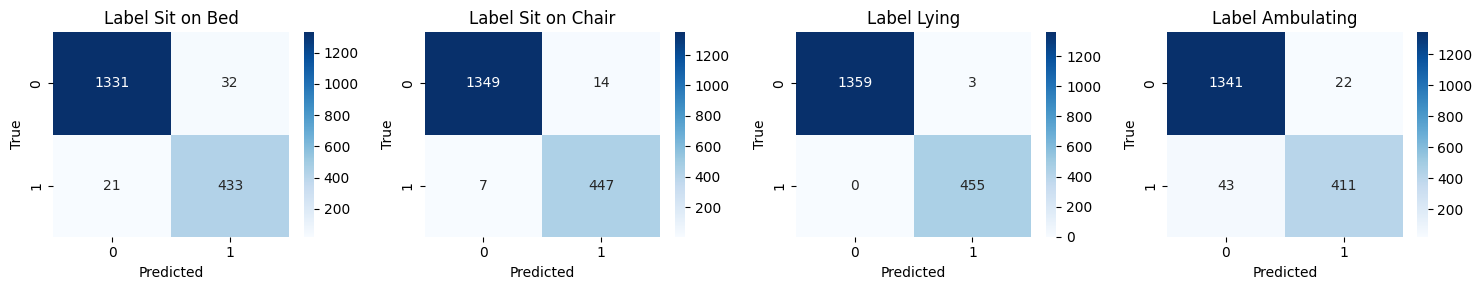


Classification Report:
               precision    recall  f1-score   support

           1       0.93      0.95      0.94       454
           2       0.97      0.98      0.98       454
           3       0.99      1.00      1.00       455
           4       0.95      0.91      0.93       454

    accuracy                           0.96      1817
   macro avg       0.96      0.96      0.96      1817
weighted avg       0.96      0.96      0.96      1817

Accuracy =  0.9609246009906439
Precision =  0.9608638749282675
Recall =  0.9609030837004405
F1 Score = 0.9607028015254931


In [88]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=100, random_state=42)

#Training and evaluating model
RF_model = final_model(classifier)

#### Save Best model

In [89]:
import joblib

# Define the model filename
model_filename = "RF_model.pkl"

# Save the trained stacking classifier
joblib.dump(RF_model, model_filename)

print(f"Model saved successfully as {model_filename}")

Model saved successfully as RF_model.pkl


In [90]:
# Load the saved model
loaded_model = joblib.load(model_filename)